# team4d nutrient clustering and modeling

This notebook starts from the nutrient-complete table.

The goal here is simple:
- look for broad nutrient and water-quality regimes
- test whether water and air conditions can explain nutrient levels


## 1) dependencies


In [1]:
# basic tools for paths tables and charts
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn gives us simple clustering and prediction tools
from sklearn.cluster import DBSCAN, KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix, f1_score, mean_absolute_error, precision_score, r2_score, recall_score, roc_auc_score, root_mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# keep charts readable
sns.set_theme( style = 'whitegrid' )


## 2) load the nutrient-rich table

This file should have only rows with all nutrient and core predictor fields present.


In [ ]:
# point to the nutrient-complete file from the cleaning notebook
data_path = Path( '../Data/Team4D/team4d.baseline.1h_complete_records.csv' )

# stop early if the cleaned export is missing
if not data_path.exists( ):
    raise FileNotFoundError( f'missing file: {data_path.resolve()}' )

# load the table and parse the timestamp
data = pd.read_csv( data_path, parse_dates = [ 'datetime' ], low_memory = False )

# keep compatibility with older exports, but prefer the smaller solar-radiation unit
if 'm_ssrd_kwh_m2' not in data.columns and 'm_ssrd_j_m2' in data.columns:
    data[ 'm_ssrd_kwh_m2' ] = pd.to_numeric( data[ 'm_ssrd_j_m2' ], errors = 'coerce' ) / 3600000
    data = data.drop( columns = [ 'm_ssrd_j_m2' ] )

# keep the rows ordered by place and time
data = data.sort_values( [ 'region', 'station', 'datetime' ] ).reset_index( drop = True )

print( 'shape:', data.shape )
print( )
print( 'columns:' )
print( data.columns.tolist( ) )


FileNotFoundError: missing file: /Users/jeturcotte/Class/CDS-492/Code/team4d.baseline.8am-8pm.csv

## 3) quick structure check

Before clustering or modeling, confirm the scale of the variables we kept.


In [ ]:
# separate nutrients from water and meteorology so later cells stay readable
nutrient_cols = [ 
    'n_po4f_mg_l',
    'n_nh4f_mg_l',
    'n_no2f_mg_l',
    'n_no3f_mg_l',
    'n_no23f_mg_l',
    'n_chla_ug_l',
]

water_cols = [ 
    'w_temp_c',
    'w_sal_psu',
    'w_do_mg_l',
    'w_do_pct',
    'depth_m',
    'w_ph',
]

met_cols = [ 
    'm_wind_ms',
    'm_ssrd_kwh_m2',
    'm_precip_mmh',
    'm_temp_c',
]

print( 'rows by region:' )
print( data[ 'region' ].value_counts( ).head( 10 ) )
print( )
print( 'rows by station:' )
print( data[ 'station' ].value_counts( ).head( 10 ) )
print( )

data[ nutrient_cols + water_cols + met_cols ].describe( ).round( 3 ).T


rows by region:
region
cbm    97126
pdb    96186
niw    64134
sos    60108
rkb    40224
nar    33541
kac    28086
cbv    28032
gtm    26783
elk    25296
Name: count, dtype: int64

rows by station:
station
by    34710
cb    31513
rr    27714
ip    25757
ta    24427
bp    23132
mc    22725
jl    22187
oc    21768
ch    21618
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
n_po4f_mg_l,590186.0,0.037,0.075,0.000,0.010,0.023,0.046,21.961
n_nh4f_mg_l,590186.0,0.070,0.141,0.000,0.017,0.036,0.068,13.724
n_no2f_mg_l,590186.0,0.007,0.011,0.000,0.002,0.004,0.008,0.196
n_no3f_mg_l,590186.0,0.240,0.435,0.000,0.017,0.098,0.308,8.886
n_no23f_mg_l,590186.0,0.247,0.439,0.000,0.021,0.107,0.316,8.938
n_chla_ug_l,590186.0,7.121,12.983,0.000,1.610,3.210,7.000,354.500
w_temp_c,590186.0,16.794,7.630,-4.900,10.700,15.900,23.100,45.000
w_sal_psu,590186.0,19.613,13.416,0.000,3.200,26.300,30.700,59.400
w_do_mg_l,590186.0,7.624,2.595,0.000,5.900,7.700,9.300,24.700
w_do_pct,590186.0,85.855,24.879,0.000,73.200,88.100,99.000,299.100


## 4) add a few simple time features

These are easy predictors for seasonality and daily cycles.


In [ ]:
# pull out a few calendar pieces for later modeling
data[ 'year' ] = data[ 'datetime' ].dt.year
data[ 'month' ] = data[ 'datetime' ].dt.month
data[ 'hour' ] = data[ 'datetime' ].dt.hour

time_summary = data[ [ 'year', 'month', 'hour' ] ].describe( ).round( 2 )
print( time_summary )


            year      month       hour
count  590186.00  590186.00  590186.00
mean     2006.50       6.73      11.50
std         3.47       3.27       6.92
min      2002.00       1.00       0.00
25%      2004.00       4.00       6.00
50%      2006.00       7.00      11.00
75%      2009.00      10.00      17.00
max      2024.00      12.00      23.00


## 5) build a clustering sample

Clustering every row is possible, but a moderate sample is easier to inspect and much faster to rerun.


In [ ]:
# use nutrients and environmental conditions together for the cluster view
cluster_cols = nutrient_cols + water_cols + met_cols

# keep the sample large enough to be useful, but small enough to iterate quickly
cluster_sample_n = min( 20000, len( data ) )
cluster_sample = data.sample( n = cluster_sample_n, random_state = 42 ).copy( )

# standardize the variables so large-scale fields do not dominate the clusters
cluster_scaler = StandardScaler( )
cluster_matrix = cluster_scaler.fit_transform( cluster_sample[ cluster_cols ] )

# reduce the matrix to two axes so we can plot the clusters
cluster_pca = PCA( n_components = 2, random_state = 42 )
cluster_scores = cluster_pca.fit_transform( cluster_matrix )
cluster_sample[ 'pc1' ] = cluster_scores[ :, 0 ]
cluster_sample[ 'pc2' ] = cluster_scores[ :, 1 ]

print( f'cluster sample rows: {len( cluster_sample ):,}' )
print( )
print( 'pca explained variance:' )
print( np.round( cluster_pca.explained_variance_ratio_, 3 ) )


cluster sample rows: 20,000

pca explained variance:
[0.204 0.181]


## 6) scan a few cluster counts

This gives a quick elbow-style view and a silhouette score for separation.


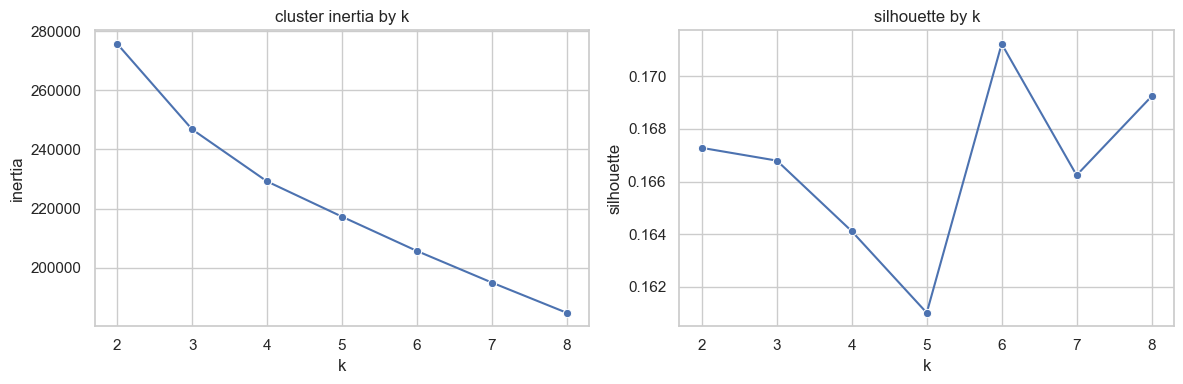

,k,inertia,silhouette
0,2,275674.939943,0.167277
1,3,246777.761276,0.166793
2,4,229192.882866,0.164109
3,5,217280.697299,0.161012
4,6,205693.359038,0.171229
5,7,195012.675879,0.166238
6,8,184798.268514,0.169231


In [ ]:
# try a small range of cluster counts
k_values = list( range( 2, 9 ) )
cluster_scan_rows = [ ]

for k in k_values:
    kmeans = KMeans( n_clusters = k, n_init = 20, random_state = 42 )
    labels = kmeans.fit_predict( cluster_matrix )

    cluster_scan_rows.append( { 
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score( cluster_matrix, labels ),
    } )

cluster_scan = pd.DataFrame( cluster_scan_rows )

fig, axes = plt.subplots( 1, 2, figsize = ( 12, 4 ) )
sns.lineplot( data = cluster_scan, x = 'k', y = 'inertia', marker = 'o', ax = axes[ 0 ] )
sns.lineplot( data = cluster_scan, x = 'k', y = 'silhouette', marker = 'o', ax = axes[ 1 ] )
axes[ 0 ].set_title( 'cluster inertia by k' )
axes[ 1 ].set_title( 'silhouette by k' )
plt.tight_layout( )
plt.show( )

cluster_scan


## reading the cluster scan

### method note

This clustering pass uses three steps:
- standardize the nutrient water-quality and meteorology columns so large-unit fields do not dominate
- reduce the data to two PCA axes for plotting only
- fit K-means on the full standardized cluster matrix

### interpretation note

The silhouette scores here are modest, around `0.16` to `0.17`. That means the data do not split into sharply separated natural groups. In practical terms, these clusters should be read as broad environmental regimes, not hard biological types.

The inertia curve keeps improving as `k` grows, which is normal. That is why this notebook uses `k = 4` as a readable starting point rather than claiming it is the one correct answer. A later pass can compare `k = 4` with `k = 6` because `k = 6` had the best silhouette in this baseline run.


## 7) fit one first-pass clustering solution

[Use a small fixed `k` for now, then inspect the cluster profiles.](https://medium.com/@jeffzyme/understanding-inertia-distortion-and-silhouette-scores-and-their-differences-key-metrics-for-458fe28ce2aa)


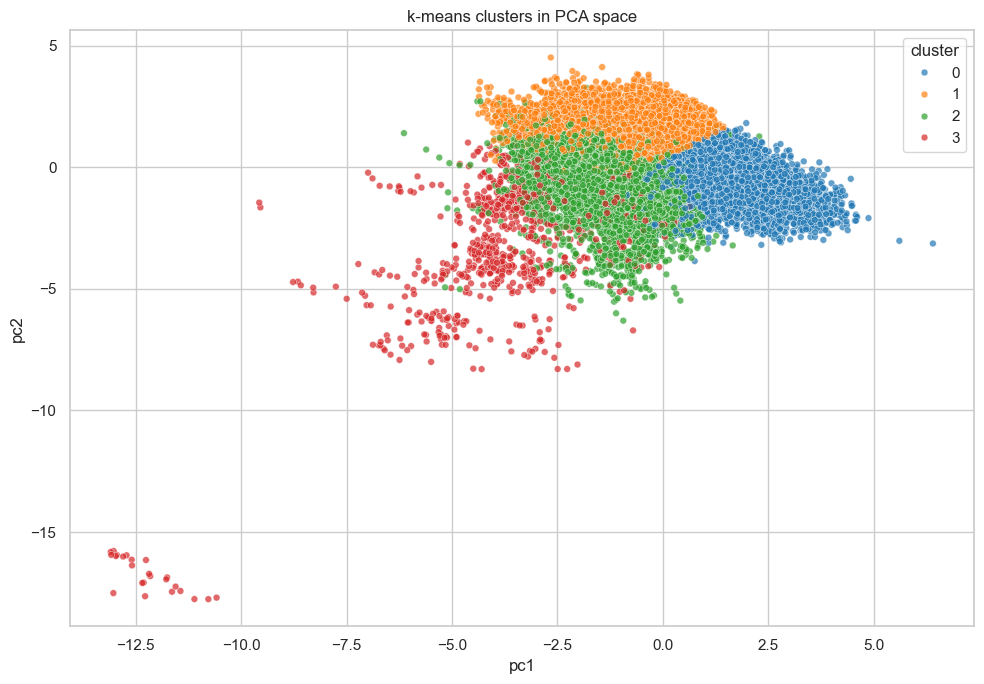

cluster sizes:
cluster
0    8238
1    5744
2    5189
3     829
Name: count, dtype: int64



,n_po4f_mg_l,n_nh4f_mg_l,n_no2f_mg_l,n_no3f_mg_l,n_no23f_mg_l,n_chla_ug_l,w_temp_c,w_sal_psu,w_do_mg_l,w_do_pct,depth_m,w_ph,m_wind_ms,m_ssrd_kwh_m2,m_precip_mmh,m_temp_c
cluster,,,,,,,,,,,,,,,,
0,0.037,0.037,0.005,0.142,0.147,3.261,11.469,27.756,9.226,100.099,2.566,8.017,4.238,0.147,0.136,10.269
1,0.030,0.061,0.005,0.047,0.052,6.691,24.511,25.364,5.079,70.520,1.543,7.609,3.667,0.237,0.132,23.550
2,0.045,0.059,0.009,0.458,0.468,13.963,17.114,2.113,8.144,83.988,1.067,7.181,3.320,0.185,0.120,15.894
3,0.032,0.552,0.037,1.280,1.318,4.538,13.226,7.966,6.253,62.944,1.064,7.131,2.702,0.141,0.133,10.029


In [ ]:
# start with four broad regimes and adjust later if the scan suggests otherwise
k = 4
kmeans = KMeans( n_clusters = k, n_init = 20, random_state = 42 )
cluster_sample[ 'cluster' ] = kmeans.fit_predict( cluster_matrix )

plt.figure( figsize = ( 10, 7 ) )
sns.scatterplot( 
    data = cluster_sample,
    x = 'pc1',
    y = 'pc2',
    hue = 'cluster',
    palette = 'tab10',
    s = 24,
    alpha = 0.7,
)
plt.title( 'k-means clusters in PCA space' )
plt.tight_layout( )
plt.show( )

print( 'cluster sizes:' )
print( cluster_sample[ 'cluster' ].value_counts( ).sort_index( ) )
print( )

cluster_profile_cols = nutrient_cols + water_cols + met_cols
cluster_profile = cluster_sample.groupby( 'cluster' )[ cluster_profile_cols ].mean( ).round( 3 )
cluster_profile


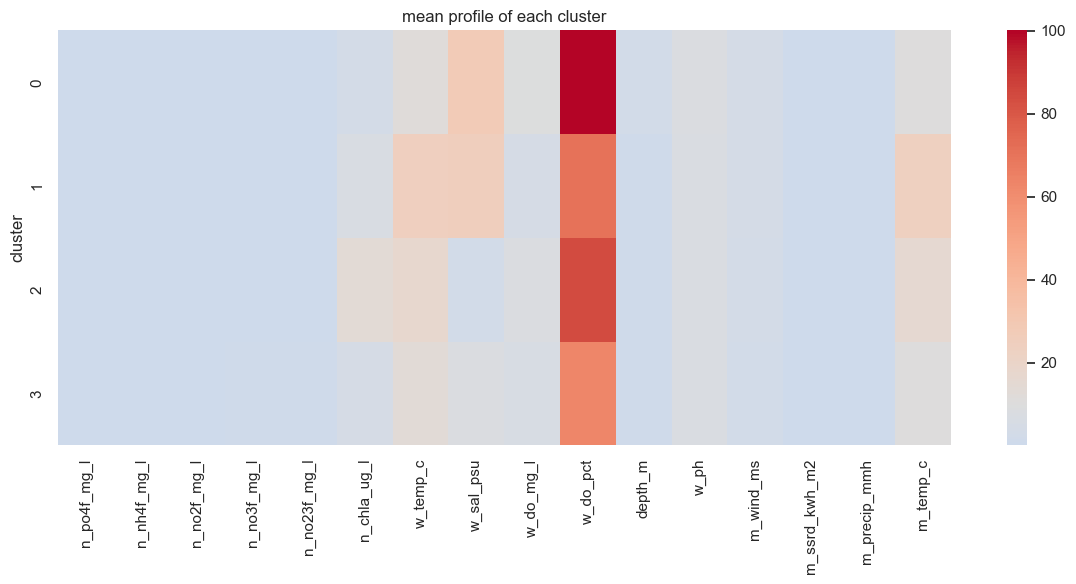

In [ ]:
# a heatmap makes the cluster profile easier to scan than a wide table
plt.figure( figsize = ( 12, 6 ) )
sns.heatmap( cluster_profile, cmap = 'coolwarm', center = cluster_profile.values.mean( ) )
plt.title( 'mean profile of each cluster' )
plt.tight_layout( )
plt.show( )


## interpreting the current clusters

These interpretations come from the cluster mean table and heatmap above.

- `cluster 0`: cool, saline, well-oxygenated water with relatively low nutrients and low chlorophyll. This looks like a cleaner marine-leaning regime.
- `cluster 1`: warm water with moderate salinity, lower dissolved oxygen, and higher chlorophyll, but not especially high nitrate. This looks like a warm productive regime where algal biomass is elevated even without the largest dissolved inorganic nitrogen values.
- `cluster 2`: low-salinity water with clearly elevated nitrate, nitrate-plus-nitrite, and chlorophyll. This looks like a fresher nutrient-rich regime with stronger bloom potential.
- `cluster 3`: the smallest cluster, but the most chemically extreme for ammonium, nitrite, nitrate, and nitrate-plus-nitrite. This looks like a rare high-nutrient event regime rather than a common background state.

A useful pattern here is that salinity helps separate the more marine cluster from the fresher nutrient-heavy clusters, while temperature and oxygen help separate the cooler stable waters from the warmer more biologically active waters.


## quantify and label the clusters

The cluster heatmap is useful, but it is still qualitative.

This next section moves one step closer to a defensible label:
- express each cluster center in standardized units
- list the strongest high and low signals in each cluster
- assign a short heuristic label based on those signals

These labels are still interpretive, not final ground truth.

Also note that the clustering step already ignores `region` and `station`. That means these groups are being formed from chemistry, water conditions, and meteorology, not from place names.


In [ ]:
# put the cluster centers into a table so each variable is on the same z-score scale
cluster_center_z = pd.DataFrame( kmeans.cluster_centers_, columns = cluster_cols )
cluster_center_z.index.name = 'cluster'

label_rows = [ ]

for cluster_id in cluster_center_z.index:
    center = cluster_center_z.loc[ cluster_id ]
    high_vars = center.sort_values( ascending = False ).head( 3 )
    low_vars = center.sort_values( ascending = True ).head( 3 )

    label = 'mixed estuary regime'
    rationale = 'no single pattern dominated the simple rule set'

    if center[ 'n_nh4f_mg_l' ] > 1.5 or center[ 'n_no3f_mg_l' ] > 1.5 or center[ 'n_no23f_mg_l' ] > 1.5:
        label = 'extreme inorganic nutrient pulse regime'
        rationale = 'the strongest standardized nutrient signals sit in ammonium and nitrate-family variables'

    elif center[ 'w_sal_psu' ] < -1.0 and center[ 'n_no23f_mg_l' ] > 0.3 and center[ 'n_chla_ug_l' ] > 0.3:
        label = 'fresh nitrate-rich bloom-prone regime'
        rationale = 'fresher water with elevated nitrate-family nutrients and chlorophyll'

    elif center[ 'w_temp_c' ] > 0.8 and center[ 'w_do_mg_l' ] < -0.5 and center[ 'w_sal_psu' ] > 0:
        label = 'warm productive lower-oxygen regime'
        rationale = 'warmer moderate-salinity water with lower dissolved oxygen and productive conditions'

    elif center[ 'w_sal_psu' ] > 0.5 and center[ 'w_do_mg_l' ] > 0.5 and center[ 'w_temp_c' ] < -0.5:
        label = 'cool saline oxygen-rich low-nutrient regime'
        rationale = 'cooler saline water with stronger oxygen conditions and lower nutrient stress'

    label_rows.append( { 
        'cluster': cluster_id,
        'label': label,
        'rationale': rationale,
        'top_high_signals': ', '.join( [ f'{name} ({value:0.2f})' for name, value in high_vars.items( ) ] ),
        'top_low_signals': ', '.join( [ f'{name} ({value:0.2f})' for name, value in low_vars.items( ) ] ),
    } )

cluster_labels = pd.DataFrame( label_rows ).sort_values( 'cluster' )
cluster_labels


,cluster,label,rationale,top_high_signals,top_low_signals
0,0,cool saline oxygen-rich low-nutrient regime,cooler saline water with stronger oxygen condi...,"w_ph (0.66), w_do_mg_l (0.62), w_sal_psu (0.61)","w_temp_c (-0.69), m_temp_c (-0.60), n_chla_ug_..."
1,1,warm productive lower-oxygen regime,warmer moderate-salinity water with lower diss...,"w_temp_c (1.02), m_temp_c (0.92), w_sal_psu (0...","w_do_mg_l (-0.99), w_do_pct (-0.62), n_no23f_m..."
2,2,fresh nitrate-rich bloom-prone regime,fresher water with elevated nitrate-family nut...,"n_chla_ug_l (0.53), n_no23f_mg_l (0.47), n_no3...","w_sal_psu (-1.30), w_ph (-0.83), depth_m (-0.40)"
3,3,extreme inorganic nutrient pulse regime,the strongest standardized nutrient signals si...,"n_nh4f_mg_l (3.40), n_no2f_mg_l (2.62), n_no23...","w_do_pct (-0.92), w_ph (-0.92), w_sal_psu (-0.87)"


In [ ]:
# combine the labels with the mean profile so the names stay tied to the evidence
cluster_summary = cluster_labels.merge( cluster_profile.reset_index( ), on = 'cluster', how = 'left' )
cluster_summary


,cluster,label,rationale,top_high_signals,top_low_signals,n_po4f_mg_l,n_nh4f_mg_l,n_no2f_mg_l,n_no3f_mg_l,n_no23f_mg_l,...,w_temp_c,w_sal_psu,w_do_mg_l,w_do_pct,depth_m,w_ph,m_wind_ms,m_ssrd_kwh_m2,m_precip_mmh,m_temp_c
0,0,cool saline oxygen-rich low-nutrient regime,cooler saline water with stronger oxygen condi...,"w_ph (0.66), w_do_mg_l (0.62), w_sal_psu (0.61)","w_temp_c (-0.69), m_temp_c (-0.60), n_chla_ug_...",0.037,0.037,0.005,0.142,0.147,...,11.469,27.756,9.226,100.099,2.566,8.017,4.238,0.147,0.136,10.269
1,1,warm productive lower-oxygen regime,warmer moderate-salinity water with lower diss...,"w_temp_c (1.02), m_temp_c (0.92), w_sal_psu (0...","w_do_mg_l (-0.99), w_do_pct (-0.62), n_no23f_m...",0.030,0.061,0.005,0.047,0.052,...,24.511,25.364,5.079,70.520,1.543,7.609,3.667,0.237,0.132,23.550
2,2,fresh nitrate-rich bloom-prone regime,fresher water with elevated nitrate-family nut...,"n_chla_ug_l (0.53), n_no23f_mg_l (0.47), n_no3...","w_sal_psu (-1.30), w_ph (-0.83), depth_m (-0.40)",0.045,0.059,0.009,0.458,0.468,...,17.114,2.113,8.144,83.988,1.067,7.181,3.320,0.185,0.120,15.894
3,3,extreme inorganic nutrient pulse regime,the strongest standardized nutrient signals si...,"n_nh4f_mg_l (3.40), n_no2f_mg_l (2.62), n_no23...","w_do_pct (-0.92), w_ph (-0.92), w_sal_psu (-0.87)",0.032,0.552,0.037,1.280,1.318,...,13.226,7.966,6.253,62.944,1.064,7.131,2.702,0.141,0.133,10.029


## check how region mixes into the clusters

The clustering step did not use `region`, but it is still worth checking how each cluster is distributed across regions.

If one cluster is almost entirely one region, then the regime may still be a place-specific pattern. If several regions appear inside the same cluster, that is better evidence that the cluster reflects a broader environmental state.


In [ ]:
# look at which regions appear most often inside each cluster
cluster_region_share = pd.crosstab( cluster_sample[ 'cluster' ], cluster_sample[ 'region' ], normalize = 'index' ).round( 3 )

region_mix_rows = [ ]

for cluster_id in cluster_region_share.index:
    top_regions = cluster_region_share.loc[ cluster_id ].sort_values( ascending = False ).head( 5 )
    region_mix_rows.append( { 
        'cluster': cluster_id,
        'top_regions': ', '.join( [ f'{name} ({value:0.3f})' for name, value in top_regions.items( ) if value > 0 ] ),
    } )

cluster_region_summary = pd.DataFrame( region_mix_rows )
cluster_region_summary


,cluster,top_regions
0,0,"pdb (0.282), sos (0.184), nar (0.116), kac (0...."
1,1,"niw (0.221), rkb (0.217), gtm (0.119), elk (0...."
2,2,"cbm (0.560), niw (0.077), cbv (0.072), sfb (0...."
3,3,"pdb (0.776), cbm (0.094), gtm (0.049), cbv (0...."


## 8) build a first modeling table

For a first pass, use water quality, meteorology, time, region, and station to predict each nutrient field.


In [ ]:
# use a moderate sample so the first pass stays responsive
model_sample_n = min( 50000, len( data ) )

if len( data ) > model_sample_n:
    model_data = data.sample( n = model_sample_n, random_state = 42 ).copy( )

else:
    model_data = data.copy( )

# keep the predictors simple and transparent
model_feature_cols = water_cols + met_cols + [ 'month', 'hour', 'year' ]
X_num = model_data[ model_feature_cols ].copy( )
X_cat = pd.get_dummies( model_data[ [ 'region', 'station' ] ], drop_first = True, dtype = int )
X = pd.concat( [ X_num, X_cat ], axis = 1 )

print( f'model rows: {len( model_data ):,}' )
print( f'model features: {X.shape[ 1 ]:,}' )


model rows: 50,000
model features: 102


## 9) run one simple model per nutrient

This is not the final modeling strategy.

It is just a fast first read on which nutrient targets look more predictable.


In [ ]:
# fit one gradient-boosted tree model per nutrient target
model_rows = [ ]
chla_predictions = pd.DataFrame( )

for target_col in nutrient_cols:
    y = model_data[ target_col ]

    X_train, X_test, y_train, y_test = train_test_split( 
        X,
        y,
        test_size = 0.2,
        random_state = 42,
    )

    model = HistGradientBoostingRegressor( 
        random_state = 42,
        learning_rate = 0.05,
        max_depth = 8,
        max_iter = 300,
    )
    model.fit( X_train, y_train )
    y_pred = model.predict( X_test )

    model_rows.append( { 
        'target': target_col,
        'r2': r2_score( y_test, y_pred ),
        'rmse': root_mean_squared_error( y_test, y_pred ),
        'mae': mean_absolute_error( y_test, y_pred ),
    } )

    if target_col == 'n_chla_ug_l':
        chla_predictions = pd.DataFrame( { 
            'actual': y_test,
            'predicted': y_pred,
        } )

model_scores = pd.DataFrame( model_rows ).sort_values( 'r2', ascending = False )
model_scores


,target,r2,rmse,mae
0,n_po4f_mg_l,0.834643,0.021107,0.010140
1,n_nh4f_mg_l,0.800569,0.059731,0.027371
4,n_no23f_mg_l,0.761528,0.215607,0.085617
3,n_no3f_mg_l,0.755388,0.216314,0.084557
2,n_no2f_mg_l,0.750472,0.005603,0.002800
5,n_chla_ug_l,0.702598,6.984625,3.260072


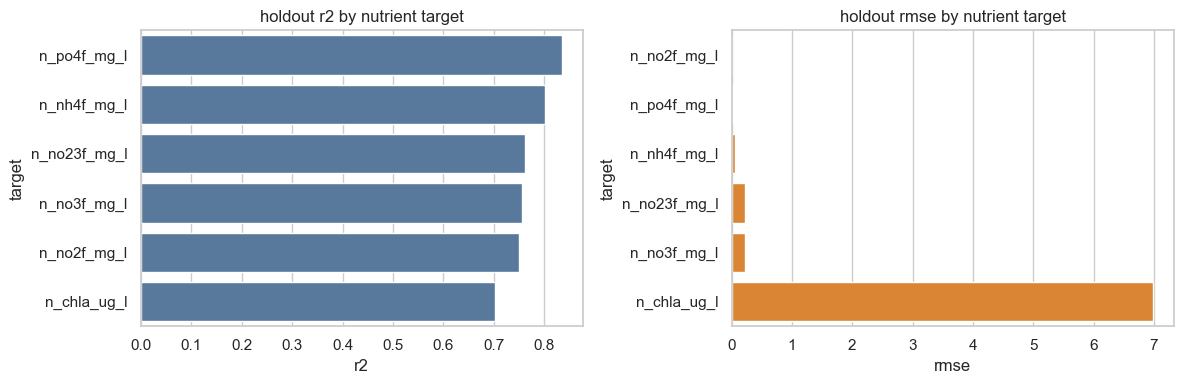

In [ ]:
# compare the nutrient targets side by side
fig, axes = plt.subplots( 1, 2, figsize = ( 12, 4 ) )
sns.barplot( data = model_scores, x = 'r2', y = 'target', color = '#4c78a8', ax = axes[ 0 ] )
sns.barplot( data = model_scores.sort_values( 'rmse', ascending = True ), x = 'rmse', y = 'target', color = '#f58518', ax = axes[ 1 ] )
axes[ 0 ].set_title( 'holdout r2 by nutrient target' )
axes[ 1 ].set_title( 'holdout rmse by nutrient target' )
plt.tight_layout( )
plt.show( )


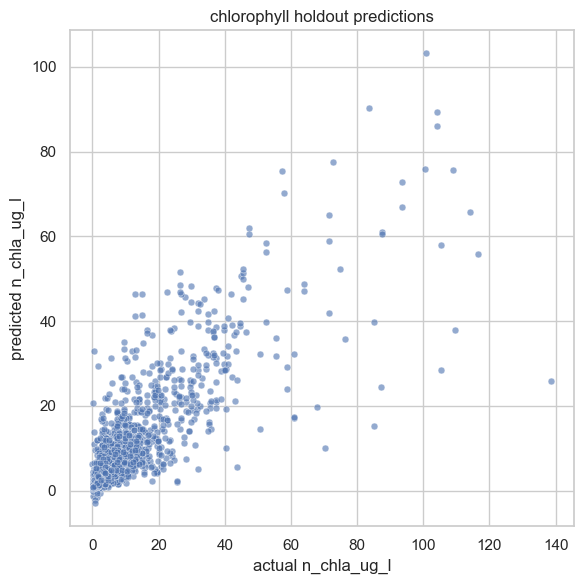

In [ ]:
# use chlorophyll as one concrete prediction example
if not chla_predictions.empty:
    plt.figure( figsize = ( 6, 6 ) )
    sns.scatterplot( data = chla_predictions.sample( n = min( 3000, len( chla_predictions ) ), random_state = 42 ), x = 'actual', y = 'predicted', s = 24, alpha = 0.6 )
    plt.xlabel( 'actual n_chla_ug_l' )
    plt.ylabel( 'predicted n_chla_ug_l' )
    plt.title( 'chlorophyll holdout predictions' )
    plt.tight_layout( )
    plt.show( )


## interpreting the baseline models

### method note

Each target gets its own `HistGradientBoostingRegressor`. This is a tree-based model from scikit-learn that handles nonlinear relationships well without requiring heavy feature engineering first.

The predictors are intentionally simple:
- water-quality columns
- meteorology columns
- time fields: `year`, `month`, `hour`
- one-hot encoded `region` and `station`

This makes the baseline easy to explain, but it also means the model can use site identity and seasonality as strong cues. That is useful for prediction, but it is not the same thing as proving a causal mechanism.

### result note

In the baseline run, phosphate and ammonium were the most predictable targets, with `r2` around `0.83` and `0.80`. Nitrate-family variables were also fairly predictable, around `0.75` to `0.76`. Chlorophyll was the hardest target, with `r2` around `0.70`, which makes sense because chlorophyll reflects more delayed and biological processes than the dissolved nutrient measures do.

A practical reading is:
- the water-quality and air variables do contain strong signal for nutrient conditions
- chlorophyll likely needs richer features, such as lagged weather, lagged nutrients, or station-specific history
- `n_no3f_mg_l` and `n_no23f_mg_l` behave very similarly, so later modeling may not need both in every analysis

This notebook should be treated as a baseline. The next modeling pass should test time-aware train/test splits and feature importance so we can separate memorization of place and season from more general environmental response patterns.


## 10) run the baseline models without place identifiers

The earlier models used `region` and `station` dummies. That is useful for prediction, but it can also let the model lean on local memory.

This section keeps the same model class, but removes `region` and `station`.

That gives a cleaner test of whether the water and air variables alone carry enough signal to describe nutrient dynamics in a more transportable way.


In [ ]:
# rebuild the feature table without any place identifiers
X_no_place = model_data[ model_feature_cols ].copy( )

print( f'no-place model rows: {len( model_data ):,}' )
print( f'no-place model features: {X_no_place.shape[ 1 ]:,}' )


no-place model rows: 50,000
no-place model features: 13


In [ ]:
# fit the same regressor again so we can see what changes without region or station
no_place_rows = [ ]

for target_col in nutrient_cols:
    y = model_data[ target_col ]

    X_train, X_test, y_train, y_test = train_test_split( 
        X_no_place,
        y,
        test_size = 0.2,
        random_state = 42,
    )

    model = HistGradientBoostingRegressor( 
        random_state = 42,
        learning_rate = 0.05,
        max_depth = 8,
        max_iter = 300,
    )
    model.fit( X_train, y_train )
    y_pred = model.predict( X_test )

    no_place_rows.append( { 
        'target': target_col,
        'r2_no_place': r2_score( y_test, y_pred ),
        'rmse_no_place': root_mean_squared_error( y_test, y_pred ),
        'mae_no_place': mean_absolute_error( y_test, y_pred ),
    } )

no_place_scores = pd.DataFrame( no_place_rows ).sort_values( 'r2_no_place', ascending = False )
no_place_scores


,target,r2_no_place,rmse_no_place,mae_no_place
4,n_no23f_mg_l,0.607569,0.276583,0.123384
1,n_nh4f_mg_l,0.591003,0.085539,0.039343
3,n_no3f_mg_l,0.579105,0.283748,0.128691
2,n_no2f_mg_l,0.557163,0.007464,0.003772
0,n_po4f_mg_l,0.547854,0.034903,0.017587
5,n_chla_ug_l,0.483260,9.206766,4.290659


In [ ]:
# compare the place-aware and no-place scores side by side
model_compare = model_scores.merge( no_place_scores, on = 'target', how = 'left' )
model_compare[ 'r2_drop_without_place' ] = model_compare[ 'r2' ] - model_compare[ 'r2_no_place' ]
model_compare = model_compare.sort_values( 'r2_drop_without_place', ascending = False )
model_compare


,target,r2,rmse,mae,r2_no_place,rmse_no_place,mae_no_place,r2_drop_without_place
0,n_po4f_mg_l,0.834643,0.021107,0.010140,0.547854,0.034903,0.017587,0.286789
5,n_chla_ug_l,0.702598,6.984625,3.260072,0.483260,9.206766,4.290659,0.219338
1,n_nh4f_mg_l,0.800569,0.059731,0.027371,0.591003,0.085539,0.039343,0.209567
4,n_no2f_mg_l,0.750472,0.005603,0.002800,0.557163,0.007464,0.003772,0.193309
3,n_no3f_mg_l,0.755388,0.216314,0.084557,0.579105,0.283748,0.128691,0.176283
2,n_no23f_mg_l,0.761528,0.215607,0.085617,0.607569,0.276583,0.123384,0.153959


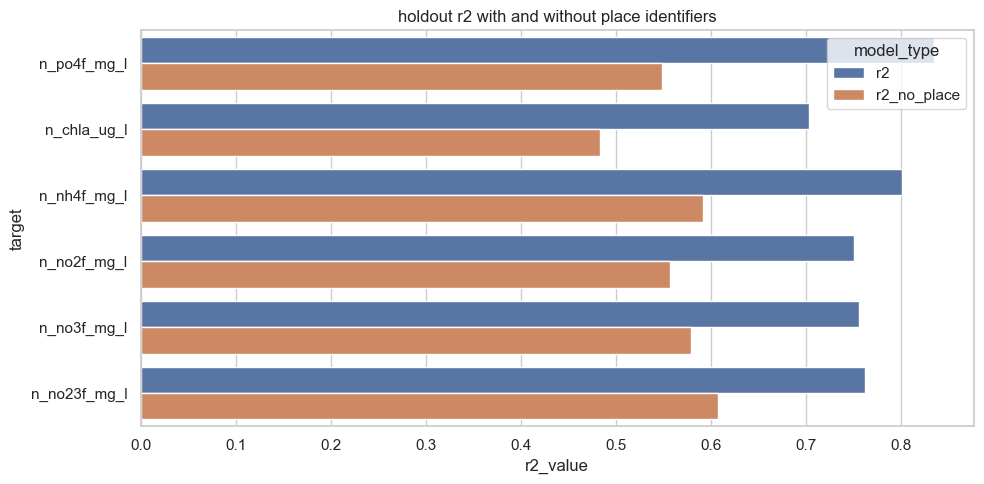

In [ ]:
# plot how much predictive power falls away when region and station are removed
plot_compare = model_compare.melt( 
    id_vars = 'target',
    value_vars = [ 'r2', 'r2_no_place' ],
    var_name = 'model_type',
    value_name = 'r2_value',
)

plt.figure( figsize = ( 10, 5 ) )
sns.barplot( data = plot_compare, x = 'r2_value', y = 'target', hue = 'model_type' )
plt.title( 'holdout r2 with and without place identifiers' )
plt.tight_layout( )
plt.show( )


## interpreting the no-place model

If the no-place scores stay fairly strong, that supports the idea that nutrient conditions are being described by shared environmental dynamics rather than mostly by site identity.

If the scores collapse, then place is carrying a large part of the predictive signal. In that case, the next climate-focused step would be to add better process features, such as rolling heat, recent rainfall, lagged radiation, or recent oxygen stress, instead of leaning on geography.


## 11) try a second no-place clustering pass

The earlier clustering used nutrients, water quality, and meteorology together.

This second pass is stricter:
- do not use `region` or `station`
- do not use nutrient values to form the clusters
- cluster only on water conditions, meteorology, and simple time cues

That makes the groups easier to read as environmental regimes first, and then we can ask how nutrient levels differ across those regimes.


In [ ]:
# build a no-place clustering sample from environmental predictors only
no_place_cluster_cols = water_cols + met_cols + [ 'month', 'hour' ]

no_place_cluster_n = min( 20000, len( data ) )
no_place_cluster_sample = data.sample( n = no_place_cluster_n, random_state = 84 ).copy( )

# standardize the columns so one unit system does not dominate the distance metric
no_place_cluster_scaler = StandardScaler( )
no_place_cluster_matrix = no_place_cluster_scaler.fit_transform( no_place_cluster_sample[ no_place_cluster_cols ] )

# use two principal components only for plotting
no_place_cluster_pca = PCA( n_components = 2, random_state = 84 )
no_place_cluster_scores = no_place_cluster_pca.fit_transform( no_place_cluster_matrix )
no_place_cluster_sample[ 'env_pc1' ] = no_place_cluster_scores[ :, 0 ]
no_place_cluster_sample[ 'env_pc2' ] = no_place_cluster_scores[ :, 1 ]

print( f'no-place cluster sample rows: {len( no_place_cluster_sample ):,}' )
print( )
print( 'no-place PCA explained variance:' )
print( np.round( no_place_cluster_pca.explained_variance_ratio_, 3 ) )


no-place cluster sample rows: 20,000

no-place PCA explained variance:
[0.254 0.173]


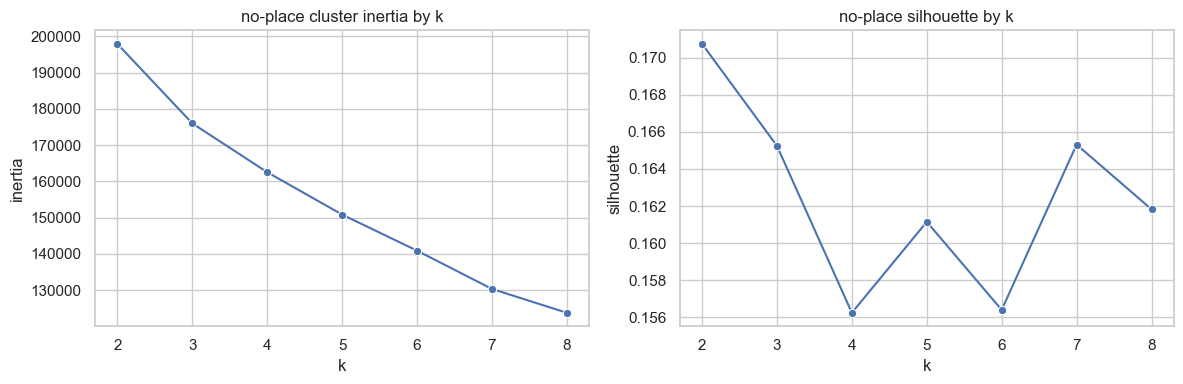

best no-place k by silhouette: 2


,k,inertia,silhouette
0,2,197962.294712,0.170748
1,3,176029.186267,0.165246
2,4,162547.279913,0.156238
3,5,150850.487881,0.161147
4,6,140891.208213,0.156396
5,7,130329.039820,0.165314
6,8,123737.039556,0.161820


In [ ]:
# scan a few cluster counts again for the predictor-only view
no_place_k_values = list( range( 2, 9 ) )
no_place_cluster_scan_rows = [ ]

for k in no_place_k_values:
    kmeans = KMeans( n_clusters = k, n_init = 20, random_state = 84 )
    labels = kmeans.fit_predict( no_place_cluster_matrix )

    no_place_cluster_scan_rows.append( { 
        'k': k,
        'inertia': kmeans.inertia_,
        'silhouette': silhouette_score( no_place_cluster_matrix, labels ),
    } )

no_place_cluster_scan = pd.DataFrame( no_place_cluster_scan_rows )
best_no_place_k = int( no_place_cluster_scan.sort_values( [ 'silhouette', 'k' ], ascending = [ False, True ] ).iloc[ 0 ][ 'k' ] )

fig, axes = plt.subplots( 1, 2, figsize = ( 12, 4 ) )
sns.lineplot( data = no_place_cluster_scan, x = 'k', y = 'inertia', marker = 'o', ax = axes[ 0 ] )
sns.lineplot( data = no_place_cluster_scan, x = 'k', y = 'silhouette', marker = 'o', ax = axes[ 1 ] )
axes[ 0 ].set_title( 'no-place cluster inertia by k' )
axes[ 1 ].set_title( 'no-place silhouette by k' )
plt.tight_layout( )
plt.show( )

print( f'best no-place k by silhouette: {best_no_place_k}' )
no_place_cluster_scan


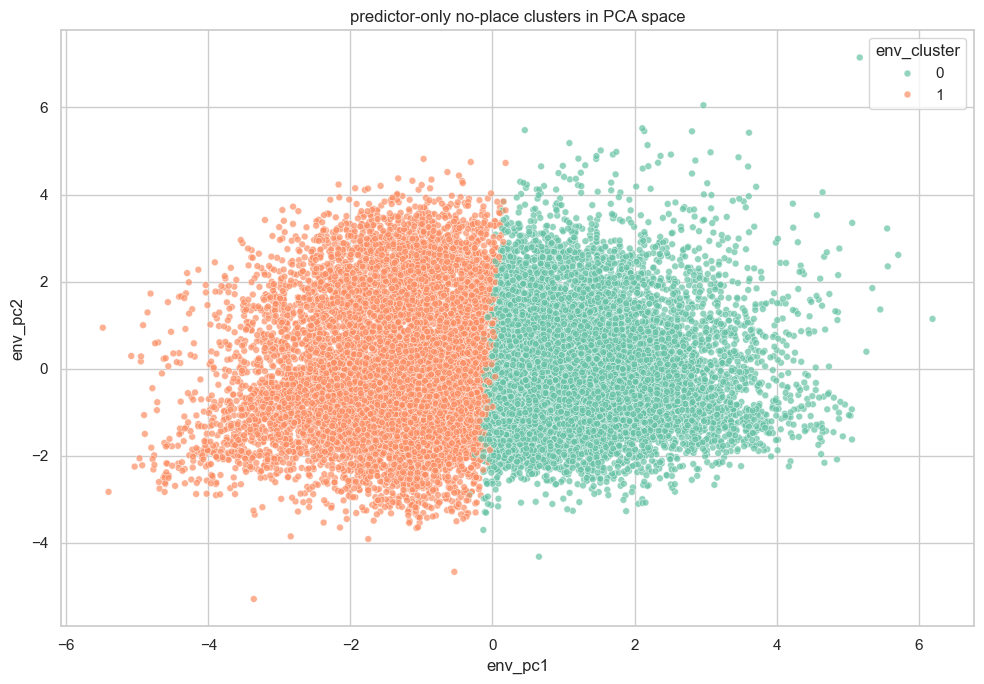

no-place cluster sizes:
env_cluster
0    10266
1     9734
Name: count, dtype: int64


In [ ]:
# fit one predictor-only clustering solution and plot it in PCA space
no_place_kmeans = KMeans( n_clusters = best_no_place_k, n_init = 20, random_state = 84 )
no_place_cluster_sample[ 'env_cluster' ] = no_place_kmeans.fit_predict( no_place_cluster_matrix )

plt.figure( figsize = ( 10, 7 ) )
sns.scatterplot( 
    data = no_place_cluster_sample,
    x = 'env_pc1',
    y = 'env_pc2',
    hue = 'env_cluster',
    palette = 'Set2',
    s = 24,
    alpha = 0.7,
)
plt.title( 'predictor-only no-place clusters in PCA space' )
plt.tight_layout( )
plt.show( )

print( 'no-place cluster sizes:' )
print( no_place_cluster_sample[ 'env_cluster' ].value_counts( ).sort_index( ) )


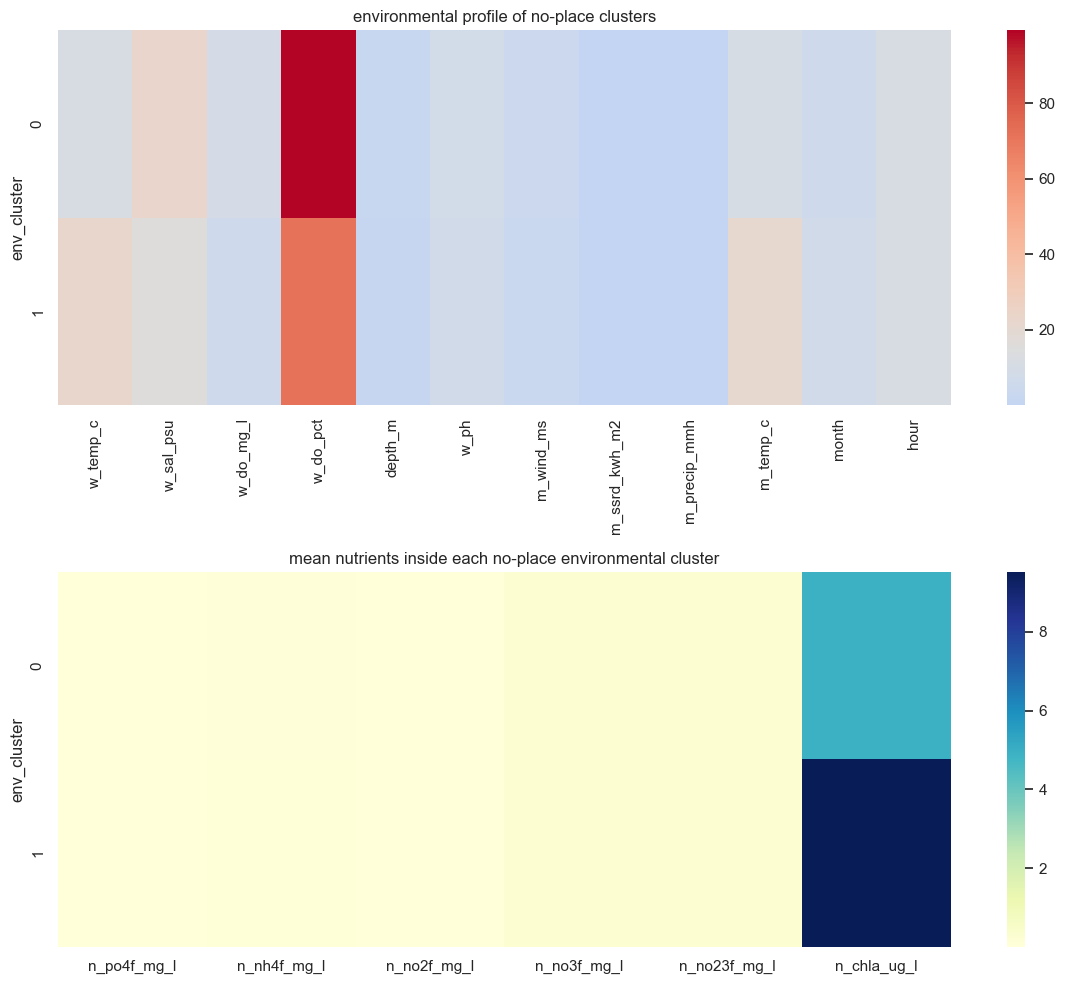

environmental profile:
             w_temp_c  w_sal_psu  w_do_mg_l  w_do_pct  depth_m   w_ph  \
env_cluster                                                             
0              11.567     22.767      9.428    99.302    2.266  7.891   
1              22.287     15.969      5.720    71.502    1.348  7.378   

             m_wind_ms  m_ssrd_kwh_m2  m_precip_mmh  m_temp_c  month    hour  
env_cluster                                                                   
0                4.227          0.151         0.136    10.246   6.27  11.621  
1                3.373          0.213         0.131    21.127   7.17  11.277  

nutrient response by environmental cluster:
             n_po4f_mg_l  n_nh4f_mg_l  n_no2f_mg_l  n_no3f_mg_l  n_no23f_mg_l  \
env_cluster                                                                     
0                  0.035        0.054        0.005        0.241         0.246   
1                  0.038        0.093        0.009        0.243         0.252   

In [ ]:
# summarize the environmental regime of each cluster in original units
no_place_cluster_profile = no_place_cluster_sample.groupby( 'env_cluster' )[ no_place_cluster_cols ].mean( ).round( 3 )

# then see how nutrients vary across those environmental regimes
no_place_cluster_nutrients = no_place_cluster_sample.groupby( 'env_cluster' )[ nutrient_cols ].mean( ).round( 3 )

fig, axes = plt.subplots( 2, 1, figsize = ( 12, 10 ) )
sns.heatmap( no_place_cluster_profile, cmap = 'coolwarm', center = no_place_cluster_profile.values.mean( ), ax = axes[ 0 ] )
axes[ 0 ].set_title( 'environmental profile of no-place clusters' )
sns.heatmap( no_place_cluster_nutrients, cmap = 'YlGnBu', ax = axes[ 1 ] )
axes[ 1 ].set_title( 'mean nutrients inside each no-place environmental cluster' )
plt.tight_layout( )
plt.show( )

print( 'environmental profile:' )
print( no_place_cluster_profile )
print( )
print( 'nutrient response by environmental cluster:' )
print( no_place_cluster_nutrients )


## interpreting the second no-place clustering pass

This second clustering pass is closer to the climate-pressure question because nutrient values did not help define the groups.

So the logic becomes:
- cluster the environmental state first
- then inspect which nutrient patterns show up inside each state

If nutrient means shift sharply across these environmental clusters, that is better evidence that water and meteorological conditions are organizing nutrient risk in a way that could matter under climate change.


## 12) try DBSCAN on the nutrient-inclusive clustering view

K-means forces every row into a cluster.

DBSCAN does something different:
- it looks for dense groups of points
- it allows irregular cluster shapes
- it can mark some rows as noise with label `-1`

That makes it useful as a second opinion on whether these nutrient and water states form dense regimes, or whether much of the data is really one broad continuum.


In [ ]:
# use a smaller sample because DBSCAN is more expensive than K-means
dbscan_sample_n = min( 8000, len( data ) )
dbscan_sample = data.sample( n = dbscan_sample_n, random_state = 126 ).copy( )

# keep the same nutrient plus environmental columns used in the earlier cluster view
dbscan_cols = cluster_cols
dbscan_scaler = StandardScaler( )
dbscan_matrix = dbscan_scaler.fit_transform( dbscan_sample[ dbscan_cols ] )

# build a PCA view for plotting only
dbscan_pca = PCA( n_components = 2, random_state = 126 )
dbscan_scores = dbscan_pca.fit_transform( dbscan_matrix )
dbscan_sample[ 'db_pc1' ] = dbscan_scores[ :, 0 ]
dbscan_sample[ 'db_pc2' ] = dbscan_scores[ :, 1 ]

print( f'dbscan nutrient-inclusive sample rows: {len( dbscan_sample ):,}' )
print( )
print( 'dbscan PCA explained variance:' )
print( np.round( dbscan_pca.explained_variance_ratio_, 3 ) )


dbscan nutrient-inclusive sample rows: 8,000

dbscan PCA explained variance:
[0.206 0.187]


In [ ]:
# use the distance to each point's 30th neighbor to pick a few eps candidates
dbscan_min_samples = 30
neighbor_model = NearestNeighbors( n_neighbors = dbscan_min_samples )
neighbor_model.fit( dbscan_matrix )
neighbor_distances, _ = neighbor_model.kneighbors( dbscan_matrix )
kth_distances = pd.Series( neighbor_distances[ :, -1 ] )
eps_candidates = sorted( kth_distances.quantile( [ 0.60, 0.70, 0.80, 0.85, 0.90, 0.95 ] ).round( 3 ).unique( ).tolist( ) )

dbscan_scan_rows = [ ]

for eps in eps_candidates:
    model = DBSCAN( eps = float( eps ), min_samples = dbscan_min_samples )
    labels = model.fit_predict( dbscan_matrix )

    label_values = sorted( [ label for label in pd.Series( labels ).unique( ).tolist( ) if label != -1 ] )
    n_clusters = len( label_values )
    noise_pct = round( 100 * pd.Series( labels ).eq( -1 ).mean( ), 2 )
    silhouette = np.nan

    non_noise_mask = labels != -1

    if n_clusters >= 2 and non_noise_mask.sum( ) >= n_clusters * 2:
        silhouette = silhouette_score( dbscan_matrix[ non_noise_mask ], labels[ non_noise_mask ] )

    dbscan_scan_rows.append( { 
        'eps': float( eps ),
        'n_clusters': n_clusters,
        'noise_pct': noise_pct,
        'silhouette_non_noise': silhouette,
    } )

dbscan_scan = pd.DataFrame( dbscan_scan_rows )
dbscan_scan = dbscan_scan.sort_values( [ 'silhouette_non_noise', 'n_clusters', 'noise_pct' ], ascending = [ False, False, True ], na_position = 'last' )
valid_dbscan_scan = dbscan_scan.loc[ dbscan_scan[ 'n_clusters' ] >= 2 ].copy( )

if len( valid_dbscan_scan ) > 0:
    best_dbscan_eps = float( valid_dbscan_scan.iloc[ 0 ][ 'eps' ] )

else:
    best_dbscan_eps = float( dbscan_scan.iloc[ 0 ][ 'eps' ] )

print( 'dbscan nutrient-inclusive eps scan:' )
dbscan_scan


dbscan nutrient-inclusive eps scan:


,eps,n_clusters,noise_pct,silhouette_non_noise
1,1.992,2,15.11,0.399416
2,2.322,2,9.80,0.390180
5,3.626,1,1.62,NaN
4,2.924,1,4.36,NaN
3,2.568,1,6.81,NaN
0,1.788,1,20.98,NaN


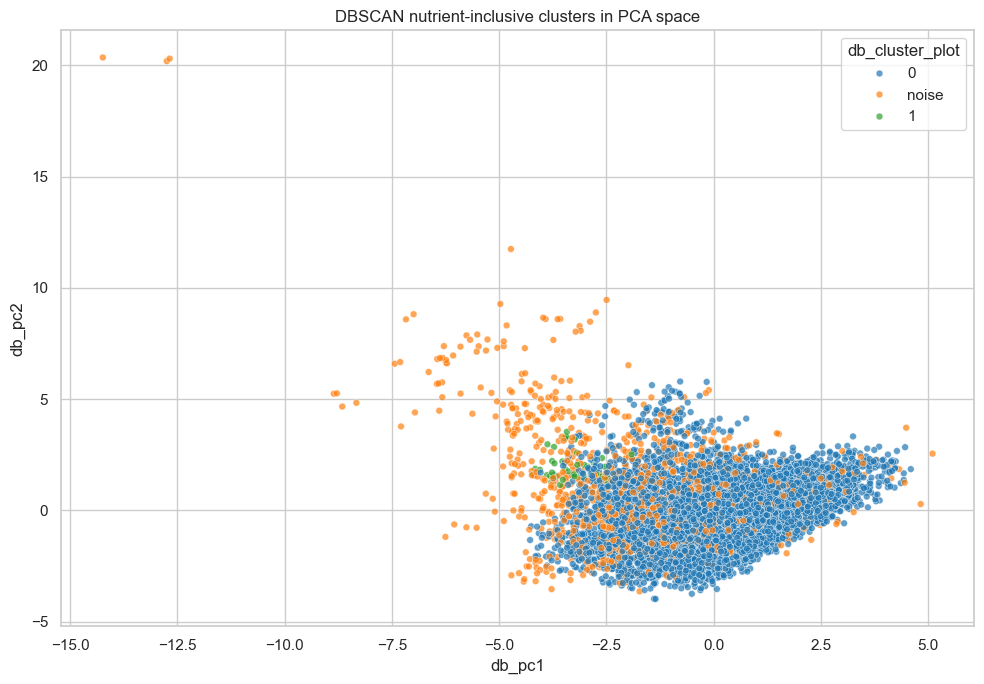

dbscan nutrient-inclusive cluster sizes:
db_cluster_plot
0        6751
noise    1209
1          40
Name: count, dtype: int64


In [ ]:
# fit one DBSCAN solution and plot it in the same PCA space
dbscan_model = DBSCAN( eps = best_dbscan_eps, min_samples = dbscan_min_samples )
dbscan_sample[ 'db_cluster' ] = dbscan_model.fit_predict( dbscan_matrix )
dbscan_sample[ 'db_cluster_plot' ] = dbscan_sample[ 'db_cluster' ].astype( str )
dbscan_sample.loc[ dbscan_sample[ 'db_cluster' ] == -1, 'db_cluster_plot' ] = 'noise'

plt.figure( figsize = ( 10, 7 ) )
sns.scatterplot( 
    data = dbscan_sample,
    x = 'db_pc1',
    y = 'db_pc2',
    hue = 'db_cluster_plot',
    palette = 'tab10',
    s = 24,
    alpha = 0.7,
)
plt.title( 'DBSCAN nutrient-inclusive clusters in PCA space' )
plt.tight_layout( )
plt.show( )

print( 'dbscan nutrient-inclusive cluster sizes:' )
print( dbscan_sample[ 'db_cluster_plot' ].value_counts( ) )


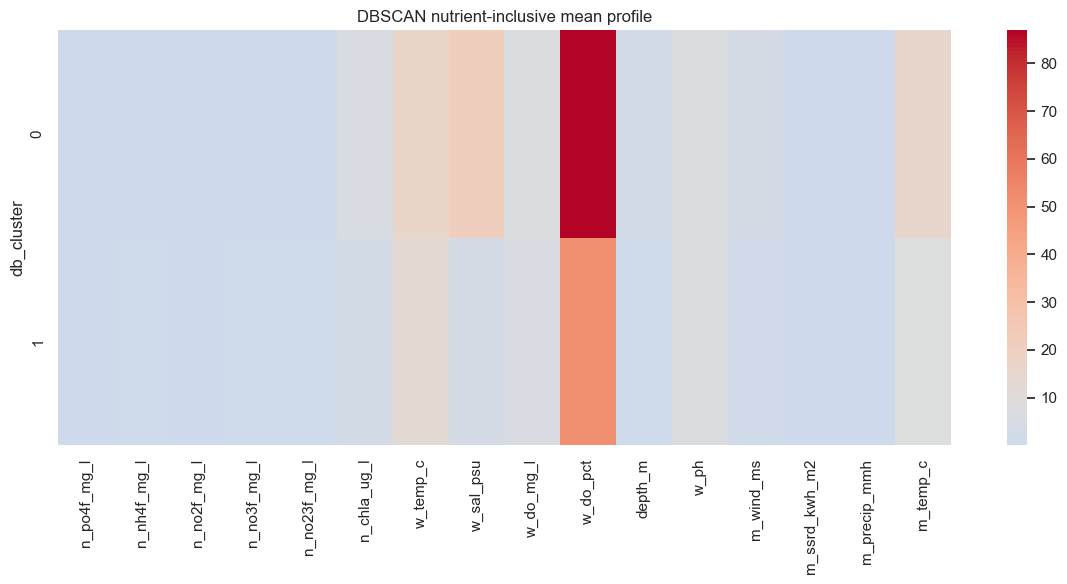

In [ ]:
# summarize only the non-noise DBSCAN groups so the profiles stay interpretable
dbscan_profile_data = dbscan_sample.loc[ dbscan_sample[ 'db_cluster' ] != -1 ].copy( )

if len( dbscan_profile_data ) > 0 and dbscan_profile_data[ 'db_cluster' ].nunique( ) > 0:
    dbscan_cluster_profile = dbscan_profile_data.groupby( 'db_cluster' )[ dbscan_cols ].mean( ).round( 3 )

    plt.figure( figsize = ( 12, 6 ) )
    sns.heatmap( dbscan_cluster_profile, cmap = 'coolwarm', center = dbscan_cluster_profile.values.mean( ) )
    plt.title( 'DBSCAN nutrient-inclusive mean profile' )
    plt.tight_layout( )
    plt.show( )

    dbscan_cluster_profile

else:
    print( 'DBSCAN did not produce a non-noise cluster profile for this scan' )


## 13) try DBSCAN on the no-place environmental clustering view

This is the stricter version for the climate-pressure question.

Here DBSCAN only sees:
- water quality
- meteorology
- month and hour

Then we inspect how nutrients behave inside those density-defined environmental states.


In [ ]:
# use a second DBSCAN sample for the predictor-only environmental view
env_dbscan_sample_n = min( 8000, len( data ) )
env_dbscan_sample = data.sample( n = env_dbscan_sample_n, random_state = 168 ).copy( )

env_dbscan_cols = no_place_cluster_cols
env_dbscan_scaler = StandardScaler( )
env_dbscan_matrix = env_dbscan_scaler.fit_transform( env_dbscan_sample[ env_dbscan_cols ] )

env_dbscan_pca = PCA( n_components = 2, random_state = 168 )
env_dbscan_scores = env_dbscan_pca.fit_transform( env_dbscan_matrix )
env_dbscan_sample[ 'env_db_pc1' ] = env_dbscan_scores[ :, 0 ]
env_dbscan_sample[ 'env_db_pc2' ] = env_dbscan_scores[ :, 1 ]

print( f'dbscan no-place sample rows: {len( env_dbscan_sample ):,}' )
print( )
print( 'dbscan no-place PCA explained variance:' )
print( np.round( env_dbscan_pca.explained_variance_ratio_, 3 ) )


dbscan no-place sample rows: 8,000

dbscan no-place PCA explained variance:
[0.257 0.168]


In [ ]:
# scan eps values again for the predictor-only environmental matrix
env_dbscan_min_samples = 30
env_neighbor_model = NearestNeighbors( n_neighbors = env_dbscan_min_samples )
env_neighbor_model.fit( env_dbscan_matrix )
env_neighbor_distances, _ = env_neighbor_model.kneighbors( env_dbscan_matrix )
env_kth_distances = pd.Series( env_neighbor_distances[ :, -1 ] )
env_eps_candidates = sorted( env_kth_distances.quantile( [ 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95 ] ).round( 3 ).unique( ).tolist( ) )

env_dbscan_scan_rows = [ ]

for eps in env_eps_candidates:
    model = DBSCAN( eps = float( eps ), min_samples = env_dbscan_min_samples )
    labels = model.fit_predict( env_dbscan_matrix )

    label_values = sorted( [ label for label in pd.Series( labels ).unique( ).tolist( ) if label != -1 ] )
    n_clusters = len( label_values )
    noise_pct = round( 100 * pd.Series( labels ).eq( -1 ).mean( ), 2 )
    silhouette = np.nan

    non_noise_mask = labels != -1

    if n_clusters >= 2 and non_noise_mask.sum( ) >= n_clusters * 2:
        silhouette = silhouette_score( env_dbscan_matrix[ non_noise_mask ], labels[ non_noise_mask ] )

    env_dbscan_scan_rows.append( { 
        'eps': float( eps ),
        'n_clusters': n_clusters,
        'noise_pct': noise_pct,
        'silhouette_non_noise': silhouette,
    } )

env_dbscan_scan = pd.DataFrame( env_dbscan_scan_rows )
env_dbscan_scan = env_dbscan_scan.sort_values( [ 'silhouette_non_noise', 'n_clusters', 'noise_pct' ], ascending = [ False, False, True ], na_position = 'last' )
valid_env_dbscan_scan = env_dbscan_scan.loc[ env_dbscan_scan[ 'n_clusters' ] >= 2 ].copy( )

if len( valid_env_dbscan_scan ) > 0:
    best_env_dbscan_eps = float( valid_env_dbscan_scan.iloc[ 0 ][ 'eps' ] )

else:
    best_env_dbscan_eps = float( env_dbscan_scan.iloc[ 0 ][ 'eps' ] )

print( 'dbscan no-place eps scan:' )
env_dbscan_scan


dbscan no-place eps scan:


,eps,n_clusters,noise_pct,silhouette_non_noise
6,2.689,1,1.45,NaN
5,2.315,1,2.75,NaN
4,1.967,1,6.84,NaN
3,1.785,1,10.72,NaN
2,1.649,1,14.81,NaN
1,1.553,1,20.28,NaN
0,1.467,1,27.49,NaN


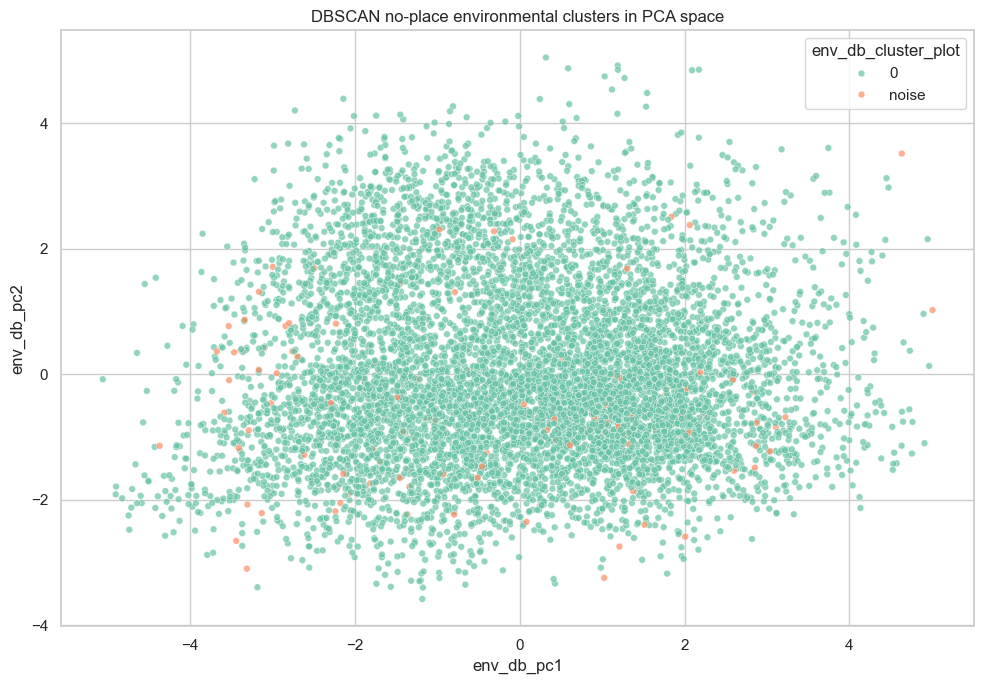

dbscan no-place cluster sizes:
env_db_cluster_plot
0        7884
noise     116
Name: count, dtype: int64


In [ ]:
# fit one predictor-only DBSCAN solution and plot it in PCA space
env_dbscan_model = DBSCAN( eps = best_env_dbscan_eps, min_samples = env_dbscan_min_samples )
env_dbscan_sample[ 'env_db_cluster' ] = env_dbscan_model.fit_predict( env_dbscan_matrix )
env_dbscan_sample[ 'env_db_cluster_plot' ] = env_dbscan_sample[ 'env_db_cluster' ].astype( str )
env_dbscan_sample.loc[ env_dbscan_sample[ 'env_db_cluster' ] == -1, 'env_db_cluster_plot' ] = 'noise'

plt.figure( figsize = ( 10, 7 ) )
sns.scatterplot( 
    data = env_dbscan_sample,
    x = 'env_db_pc1',
    y = 'env_db_pc2',
    hue = 'env_db_cluster_plot',
    palette = 'Set2',
    s = 24,
    alpha = 0.7,
)
plt.title( 'DBSCAN no-place environmental clusters in PCA space' )
plt.tight_layout( )
plt.show( )

print( 'dbscan no-place cluster sizes:' )
print( env_dbscan_sample[ 'env_db_cluster_plot' ].value_counts( ) )


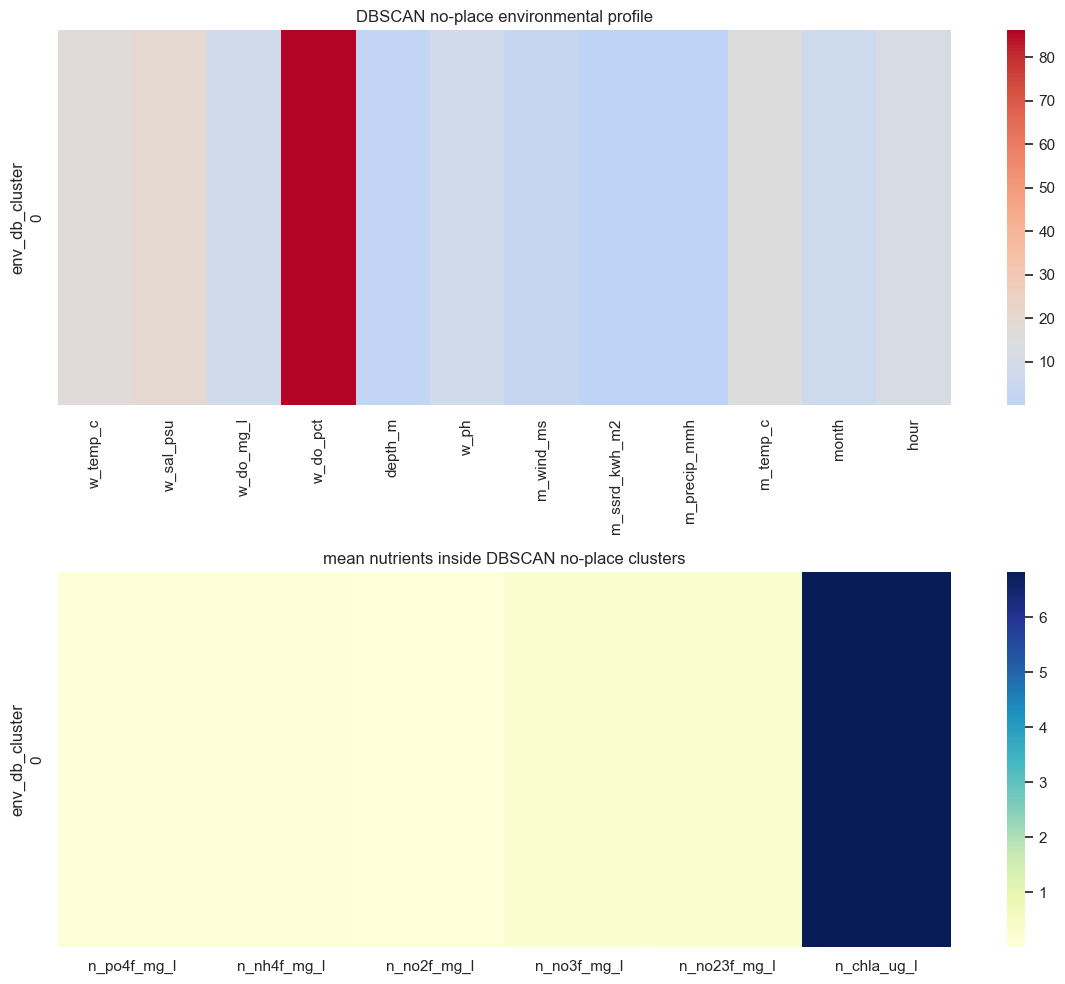

DBSCAN no-place environmental profile:
                w_temp_c  w_sal_psu  w_do_mg_l  w_do_pct  depth_m  w_ph  \
env_db_cluster                                                            
0                 16.597     19.666      7.686    86.223    1.794  7.65   

                m_wind_ms  m_ssrd_kwh_m2  m_precip_mmh  m_temp_c  month  \
env_db_cluster                                                            
0                   3.744          0.184         0.096    15.418  6.743   

                  hour  
env_db_cluster          
0               11.495  

DBSCAN no-place nutrients by environmental cluster:
                n_po4f_mg_l  n_nh4f_mg_l  n_no2f_mg_l  n_no3f_mg_l  \
env_db_cluster                                                       
0                     0.037        0.069        0.007        0.241   

                n_no23f_mg_l  n_chla_ug_l  
env_db_cluster                             
0                      0.248        6.819  


In [ ]:
# summarize the environmental regimes and the nutrient response inside them
env_dbscan_profile_data = env_dbscan_sample.loc[ env_dbscan_sample[ 'env_db_cluster' ] != -1 ].copy( )

if len( env_dbscan_profile_data ) > 0 and env_dbscan_profile_data[ 'env_db_cluster' ].nunique( ) > 0:
    env_dbscan_profile = env_dbscan_profile_data.groupby( 'env_db_cluster' )[ env_dbscan_cols ].mean( ).round( 3 )
    env_dbscan_nutrients = env_dbscan_profile_data.groupby( 'env_db_cluster' )[ nutrient_cols ].mean( ).round( 3 )

    fig, axes = plt.subplots( 2, 1, figsize = ( 12, 10 ) )
    sns.heatmap( env_dbscan_profile, cmap = 'coolwarm', center = env_dbscan_profile.values.mean( ), ax = axes[ 0 ] )
    axes[ 0 ].set_title( 'DBSCAN no-place environmental profile' )
    sns.heatmap( env_dbscan_nutrients, cmap = 'YlGnBu', ax = axes[ 1 ] )
    axes[ 1 ].set_title( 'mean nutrients inside DBSCAN no-place clusters' )
    plt.tight_layout( )
    plt.show( )

    print( 'DBSCAN no-place environmental profile:' )
    print( env_dbscan_profile )
    print( )
    print( 'DBSCAN no-place nutrients by environmental cluster:' )
    print( env_dbscan_nutrients )

else:
    print( 'DBSCAN did not produce a non-noise environmental profile for this scan' )


## 14) classify algal bloom conditions

This section treats chlorophyll-a as the bloom signal.

For a simple first pass, mark a row as a bloom when `n_chla_ug_l >= 20`. That lines up with the earlier reference table where chlorophyll-a above about `20 ug/L` starts to look eutrophic or bloom-like.

To keep the framing close to water chemistry, the predictors here are:
- the other nutrient measures
- in-water conditions such as temperature salinity oxygen depth and pH

This model does not use `region` or `station`, so it is a cleaner test of whether bloom risk can be read from the chemistry and water state alone.


In [ ]:
# define a simple binary bloom label from chlorophyll-a
bloom_threshold = 20

bloom_data = data.copy( )
bloom_data[ 'is_bloom' ] = bloom_data[ 'n_chla_ug_l' ] >= bloom_threshold

# keep this pass focused on nutrient chemistry and in-water conditions
bloom_feature_cols = [ 
    'n_po4f_mg_l',
    'n_nh4f_mg_l',
    'n_no2f_mg_l',
    'n_no3f_mg_l',
    'n_no23f_mg_l',
    'w_temp_c',
    'w_sal_psu',
    'w_do_mg_l',
    'w_do_pct',
    'depth_m',
    'w_ph',
]

bloom_model_data = bloom_data[ bloom_feature_cols + [ 'is_bloom' ] ].dropna( ).copy( )

print( f'bloom rows: {len( bloom_model_data ):,}' )
print( f"bloom prevalence: {100 * bloom_model_data[ 'is_bloom' ].mean( ):0.2f}%" )
print( )
print( bloom_model_data[ 'is_bloom' ].value_counts( ) )


bloom rows: 590,186
bloom prevalence: 7.59%

is_bloom
False    545387
True      44799
Name: count, dtype: int64


In [ ]:
# compare the average chemistry and water state in bloom and non-bloom rows
bloom_profile = bloom_model_data.groupby( 'is_bloom' )[ bloom_feature_cols ].mean( ).round( 3 )
bloom_profile.index = [ 'non_bloom', 'bloom' ]
bloom_profile


,n_po4f_mg_l,n_nh4f_mg_l,n_no2f_mg_l,n_no3f_mg_l,n_no23f_mg_l,w_temp_c,w_sal_psu,w_do_mg_l,w_do_pct,depth_m,w_ph
non_bloom,0.038,0.072,0.007,0.232,0.239,16.375,20.686,7.630,85.709,1.873,7.657
bloom,0.025,0.049,0.009,0.332,0.342,21.901,6.555,7.543,87.631,1.066,7.524


In [ ]:
# train a simple classifier to separate bloom and non-bloom rows
bloom_sample_n = min( 80000, len( bloom_model_data ) )

if len( bloom_model_data ) > bloom_sample_n:
    bloom_model_sample = bloom_model_data.sample( n = bloom_sample_n, random_state = 42 ).copy( )

else:
    bloom_model_sample = bloom_model_data.copy( )

X_bloom = bloom_model_sample[ bloom_feature_cols ].copy( )
y_bloom = bloom_model_sample[ 'is_bloom' ].astype( int )

X_train, X_test, y_train, y_test = train_test_split( 
    X_bloom,
    y_bloom,
    test_size = 0.2,
    random_state = 42,
    stratify = y_bloom,
)

bloom_model = RandomForestClassifier( 
    n_estimators = 400,
    max_depth = 12,
    min_samples_leaf = 10,
    class_weight = 'balanced_subsample',
    random_state = 42,
    n_jobs = 1,
)
bloom_model.fit( X_train, y_train )

y_pred = bloom_model.predict( X_test )
y_prob = bloom_model.predict_proba( X_test )[ :, 1 ]

bloom_scores = pd.DataFrame( { 
    'metric': [ 'balanced_accuracy', 'precision', 'recall', 'f1', 'roc_auc' ],
    'value': [ 
        balanced_accuracy_score( y_test, y_pred ),
        precision_score( y_test, y_pred, zero_division = 0 ),
        recall_score( y_test, y_pred, zero_division = 0 ),
        f1_score( y_test, y_pred, zero_division = 0 ),
        roc_auc_score( y_test, y_prob ),
    ],
} ).round( 3 )

bloom_scores


,metric,value
0,balanced_accuracy,0.969
1,precision,0.739
2,recall,0.966
3,f1,0.837
4,roc_auc,0.995


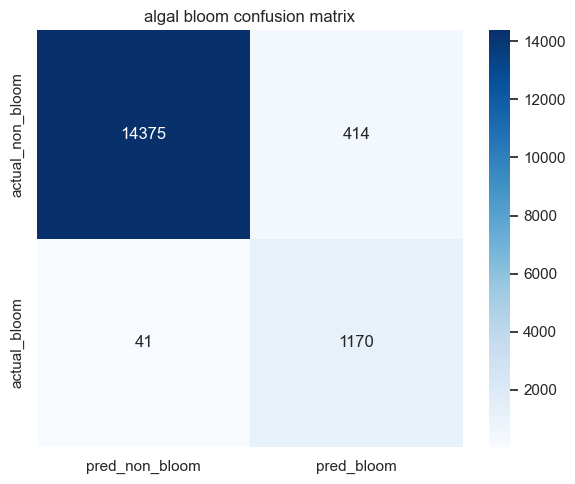

,pred_non_bloom,pred_bloom
actual_non_bloom,14375,414
actual_bloom,41,1170


In [ ]:
# show the confusion matrix as counts
bloom_cm = confusion_matrix( y_test, y_pred )
bloom_cm_df = pd.DataFrame( bloom_cm, index = [ 'actual_non_bloom', 'actual_bloom' ], columns = [ 'pred_non_bloom', 'pred_bloom' ] )

plt.figure( figsize = ( 6, 5 ) )
sns.heatmap( bloom_cm_df, annot = True, fmt = 'd', cmap = 'Blues' )
plt.title( 'algal bloom confusion matrix' )
plt.tight_layout( )
plt.show( )

bloom_cm_df


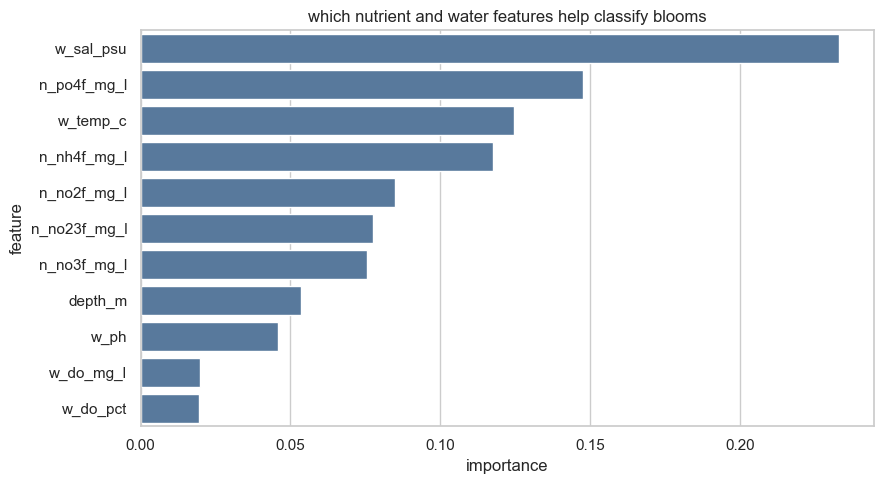

,feature,importance
6,w_sal_psu,0.233073
0,n_po4f_mg_l,0.147764
5,w_temp_c,0.124623
1,n_nh4f_mg_l,0.117627
2,n_no2f_mg_l,0.084904
4,n_no23f_mg_l,0.077710
3,n_no3f_mg_l,0.075647
9,depth_m,0.053504
10,w_ph,0.045877
7,w_do_mg_l,0.019803


In [ ]:
# rank the predictors by how much they helped the classifier split the data
bloom_importance = pd.DataFrame( { 
    'feature': bloom_feature_cols,
    'importance': bloom_model.feature_importances_,
} ).sort_values( 'importance', ascending = False )

plt.figure( figsize = ( 9, 5 ) )
sns.barplot( data = bloom_importance, x = 'importance', y = 'feature', color = '#4c78a8' )
plt.title( 'which nutrient and water features help classify blooms' )
plt.tight_layout( )
plt.show( )

bloom_importance


## interpreting the bloom classifier

This classifier is not proving causation. It is answering a narrower question: can the other nutrients and the in-water conditions help separate high-chlorophyll rows from the rest?

A few things matter when reading the results:
- the bloom class is rarer than the non-bloom class, so accuracy alone would be misleading
- `balanced_accuracy`, `precision`, and `recall` matter more here
- the feature-importance chart shows which variables helped the tree model split the bloom and non-bloom cases, but it does not by itself show direction or mechanism

If the classifier works reasonably well without place identifiers, that supports the idea that bloom risk is tied to the chemistry and water state themselves rather than only to station identity.


## 15) how bloom likelihood changes with water temperature

The classifier tells us bloom and non-bloom rows are separable, but it does not directly answer the simpler question: do blooms become more likely as water temperature rises?

This section answers that more directly by binning water temperature and measuring the share of rows above a few chlorophyll-a thresholds.

Use three cut points:
- `5 ug/L` for a looser productivity signal
- `20 ug/L` for a bloom-like signal
- `60 ug/L` for a more extreme bloom signal


In [ ]:
# bin water temperature in 1 C steps so the relationship is easy to inspect
temp_view = data[ [ 'w_temp_c', 'n_chla_ug_l' ] ].dropna( ).copy( )
temp_bin_edges = np.arange( np.floor( temp_view[ 'w_temp_c' ].min( ) ), np.ceil( temp_view[ 'w_temp_c' ].max( ) ) + 1, 1 )
temp_view[ 'temp_bin' ] = pd.cut( temp_view[ 'w_temp_c' ], bins = temp_bin_edges, right = False )

temp_bin_counts = temp_view.groupby( 'temp_bin', observed = False ).size( ).rename( 'n_rows' )
temp_bin_mid = temp_view.groupby( 'temp_bin', observed = False )[ 'w_temp_c' ].mean( ).rename( 'temp_mid_c' )

bloom_temp_rows = [ ]

for threshold in [ 5, 20, 60 ]:
    rate = temp_view.groupby( 'temp_bin', observed = False )[ 'n_chla_ug_l' ].apply( lambda s: ( s >= threshold ).mean( ) )

    temp_threshold_table = pd.concat( [ temp_bin_mid, temp_bin_counts, rate.rename( 'rate' ) ], axis = 1 ).dropna( )
    temp_threshold_table[ 'threshold_ug_l' ] = threshold
    bloom_temp_rows.append( temp_threshold_table )

bloom_temp_table = pd.concat( bloom_temp_rows ).reset_index( )
bloom_temp_table[ 'pct_rows_above_threshold' ] = 100 * bloom_temp_table[ 'rate' ]

print( bloom_temp_table.head( 12 ) )


        temp_bin  temp_mid_c  n_rows      rate  threshold_ug_l  \
0   [-5.0, -4.0)   -4.571429      14  0.714286               5   
1   [-4.0, -3.0)   -3.476190      21  0.333333               5   
2   [-3.0, -2.0)   -2.471875      32  0.437500               5   
3   [-2.0, -1.0)   -1.390909      88  0.193182               5   
4    [-1.0, 0.0)   -0.476893     515  0.295146               5   
5     [0.0, 1.0)    0.547634    1247  0.189254               5   
6     [1.0, 2.0)    1.507257    3073  0.112594               5   
7     [2.0, 3.0)    2.498578    3937  0.141986               5   
8     [3.0, 4.0)    3.503841    7629  0.111679               5   
9     [4.0, 5.0)    4.471258    8552  0.080449               5   
10    [5.0, 6.0)    5.475047   10560  0.139678               5   
11    [6.0, 7.0)    6.473464   14486  0.141723               5   

    pct_rows_above_threshold  
0                  71.428571  
1                  33.333333  
2                  43.750000  
3                

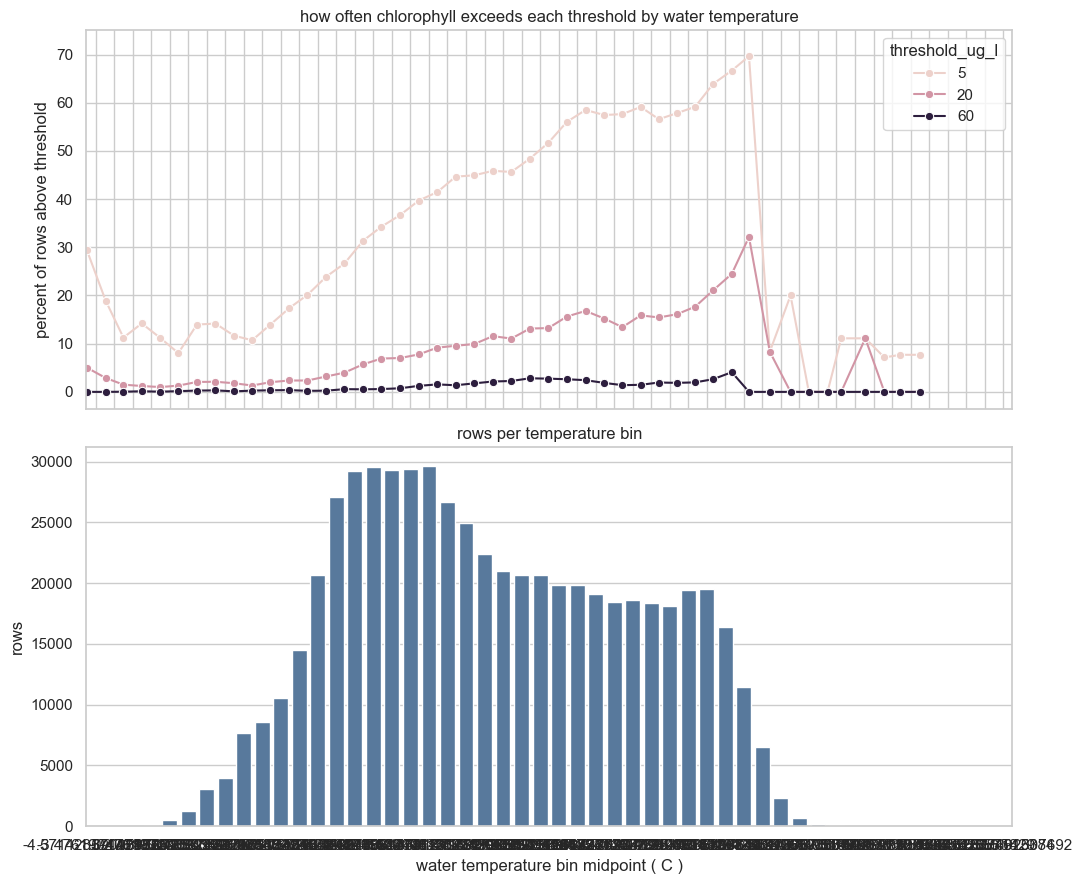

In [ ]:
# plot the bloom-rate curves and the number of rows behind each bin
fig, axes = plt.subplots( 2, 1, figsize = ( 11, 9 ), sharex = True )

sns.lineplot( 
    data = bloom_temp_table,
    x = 'temp_mid_c',
    y = 'pct_rows_above_threshold',
    hue = 'threshold_ug_l',
    marker = 'o',
    ax = axes[ 0 ],
)
axes[ 0 ].set_title( 'how often chlorophyll exceeds each threshold by water temperature' )
axes[ 0 ].set_ylabel( 'percent of rows above threshold' )

bin_count_plot = bloom_temp_table.loc[ bloom_temp_table[ 'threshold_ug_l' ] == 20, [ 'temp_mid_c', 'n_rows' ] ].copy( )
sns.barplot( data = bin_count_plot, x = 'temp_mid_c', y = 'n_rows', color = '#4c78a8', ax = axes[ 1 ] )
axes[ 1 ].set_title( 'rows per temperature bin' )
axes[ 1 ].set_xlabel( 'water temperature bin midpoint ( C )' )
axes[ 1 ].set_ylabel( 'rows' )

plt.tight_layout( )
plt.show( )


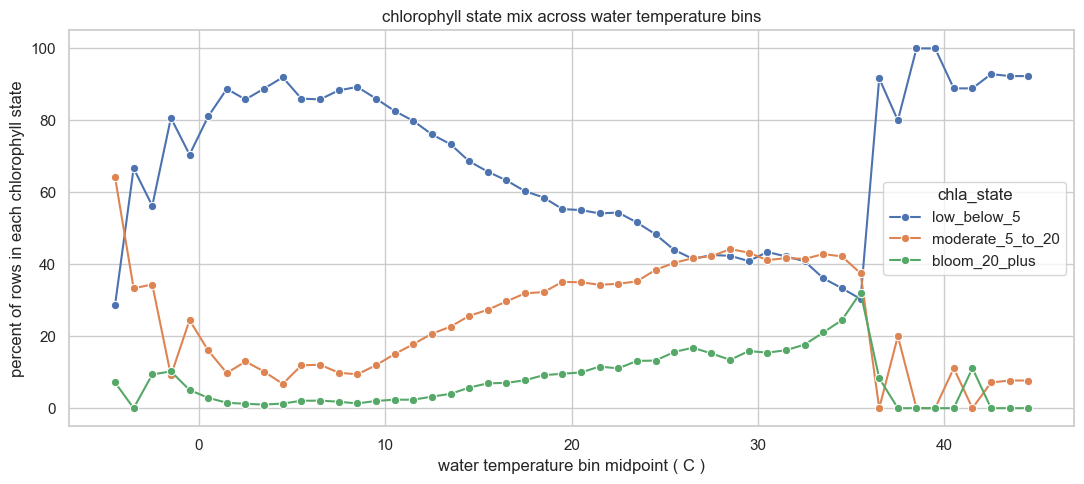

In [ ]:
# also show how the chlorophyll state mix shifts with temperature
temp_state_view = temp_view.copy( )
temp_state_view[ 'chla_state' ] = 'moderate_5_to_20'
temp_state_view.loc[ temp_state_view[ 'n_chla_ug_l' ] < 5, 'chla_state' ] = 'low_below_5'
temp_state_view.loc[ temp_state_view[ 'n_chla_ug_l' ] >= 20, 'chla_state' ] = 'bloom_20_plus'

temp_state_share = pd.crosstab( temp_state_view[ 'temp_bin' ], temp_state_view[ 'chla_state' ], normalize = 'index' )
temp_state_share = temp_state_share.reset_index( )
temp_state_share[ 'temp_mid_c' ] = temp_state_share[ 'temp_bin' ].apply( lambda x: x.left + 0.5 if pd.notna( x ) else np.nan )

state_plot = temp_state_share.melt( 
    id_vars = [ 'temp_bin', 'temp_mid_c' ],
    value_vars = [ 'low_below_5', 'moderate_5_to_20', 'bloom_20_plus' ],
    var_name = 'chla_state',
    value_name = 'share',
)
state_plot[ 'share_pct' ] = 100 * state_plot[ 'share' ]

plt.figure( figsize = ( 11, 5 ) )
sns.lineplot( data = state_plot, x = 'temp_mid_c', y = 'share_pct', hue = 'chla_state', marker = 'o' )
plt.title( 'chlorophyll state mix across water temperature bins' )
plt.xlabel( 'water temperature bin midpoint ( C )' )
plt.ylabel( 'percent of rows in each chlorophyll state' )
plt.tight_layout( )
plt.show( )


## interpreting bloom likelihood versus temperature

This view is more direct than the classifier.

If the `20 ug/L` or `60 ug/L` curves rise as water temperature rises, then bloom-like conditions are becoming more common in warmer water in this dataset.

One caution matters a lot: the hottest temperature bins can have far fewer rows. That means the far-right edge of the curve is noisier and should be read together with the row-count chart underneath it.

So the clean reading should be:
- look for broad trend across well-populated bins
- do not over-interpret the extreme tail where sample counts are thin


## 16) temporal bloom mix within cold mid and warm waters

The earlier temperature-binned view asks whether bloom likelihood rises as water warms.

This section asks a related time question:
- within cold water years, how much of the record is low moderate or bloom-like chlorophyll?
- within mid-temperature years, how does that mix change?
- within warm water years, does the bloom share become more common over time?

To keep the three panels reasonably balanced, split water temperature into three bands using dataset terciles rather than extreme fixed cutoffs.


In [ ]:
# build a time view with three water-temperature bands and three chlorophyll states
temporal_bloom_view = data[ [ 'datetime', 'w_temp_c', 'n_chla_ug_l' ] ].dropna( ).copy( )
temporal_bloom_view[ 'year' ] = temporal_bloom_view[ 'datetime' ].dt.year

temp_cut_1 = temporal_bloom_view[ 'w_temp_c' ].quantile( 1 / 3 )
temp_cut_2 = temporal_bloom_view[ 'w_temp_c' ].quantile( 2 / 3 )

temporal_bloom_view[ 'temp_band' ] = 'mid_water'
temporal_bloom_view.loc[ temporal_bloom_view[ 'w_temp_c' ] <= temp_cut_1, 'temp_band' ] = 'cold_water'
temporal_bloom_view.loc[ temporal_bloom_view[ 'w_temp_c' ] > temp_cut_2, 'temp_band' ] = 'warm_water'

temporal_bloom_view[ 'chla_state' ] = 'moderate_5_to_20'
temporal_bloom_view.loc[ temporal_bloom_view[ 'n_chla_ug_l' ] < 5, 'chla_state' ] = 'low_below_5'
temporal_bloom_view.loc[ temporal_bloom_view[ 'n_chla_ug_l' ] >= 20, 'chla_state' ] = 'bloom_20_plus'

print( f'cold / mid cut: {temp_cut_1:0.2f} C' )
print( f'mid / warm cut: {temp_cut_2:0.2f} C' )
print( )
print( temporal_bloom_view[ 'temp_band' ].value_counts( ) )


cold / mid cut: 12.30 C
mid / warm cut: 20.60 C

temp_band
mid_water     197667
cold_water    197498
warm_water    195021
Name: count, dtype: int64


In [ ]:
# calculate the annual state mix inside each water-temperature band
annual_temp_state = pd.crosstab( 
    [ temporal_bloom_view[ 'year' ], temporal_bloom_view[ 'temp_band' ] ],
    temporal_bloom_view[ 'chla_state' ],
    normalize = 'index',
)
annual_temp_state = annual_temp_state.reset_index( )

annual_temp_counts = temporal_bloom_view.groupby( [ 'year', 'temp_band' ] ).size( ).rename( 'n_rows' ).reset_index( )
annual_temp_state = annual_temp_state.merge( annual_temp_counts, on = [ 'year', 'temp_band' ], how = 'left' )

annual_temp_state.head( 12 )


,year,temp_band,bloom_20_plus,low_below_5,moderate_5_to_20,n_rows
0,2002,cold_water,0.004103,0.904514,0.091383,9017
1,2002,mid_water,0.065908,0.730632,0.203460,10636
2,2002,warm_water,0.042991,0.602344,0.354665,19283
3,2003,cold_water,0.006713,0.925561,0.067726,21897
4,2003,mid_water,0.032767,0.697257,0.269976,27558
5,2003,warm_water,0.033611,0.543670,0.422719,28681
6,2004,cold_water,0.036225,0.808518,0.155257,26556
7,2004,mid_water,0.054424,0.683117,0.262459,24842
8,2004,warm_water,0.158657,0.468732,0.372612,25697
9,2005,cold_water,0.003630,0.877330,0.119041,24521


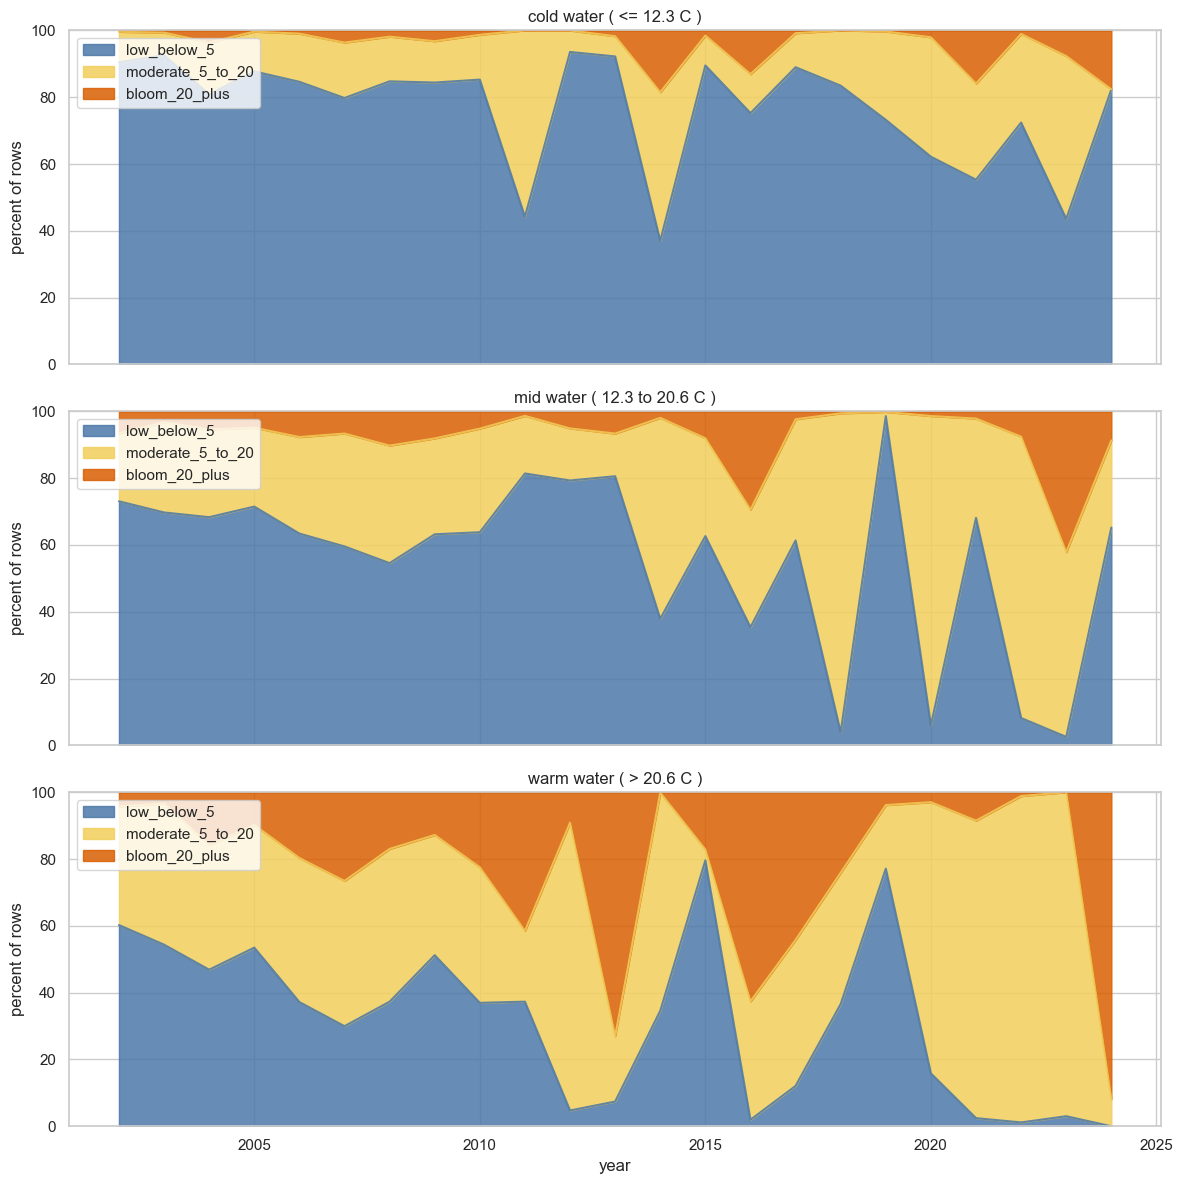

In [ ]:
# draw one temporal chart for each temperature band
band_order = [ 'cold_water', 'mid_water', 'warm_water' ]
state_order = [ 'low_below_5', 'moderate_5_to_20', 'bloom_20_plus' ]
band_titles = { 
    'cold_water': f'cold water ( <= {temp_cut_1:0.1f} C )',
    'mid_water': f'mid water ( {temp_cut_1:0.1f} to {temp_cut_2:0.1f} C )',
    'warm_water': f'warm water ( > {temp_cut_2:0.1f} C )',
}
temp_band_palette = { 
    'cold_water': '#4c78a8',
    'mid_water': '#c8a04d',
    'warm_water': '#d95f02',
}
state_colors = { 
    'low_below_5': '#4c78a8',
    'moderate_5_to_20': '#f2cf5b',
    'bloom_20_plus': '#d95f02',
}

fig, axes = plt.subplots( 3, 1, figsize = ( 12, 12 ), sharex = True )

for ax, band in zip( axes, band_order ):
    band_frame = annual_temp_state.loc[ annual_temp_state[ 'temp_band' ] == band ].copy( )
    band_frame = band_frame.sort_values( 'year' )
    band_plot = band_frame.set_index( 'year' )[ state_order ] * 100
    band_plot.plot.area( ax = ax, stacked = True, color = [ state_colors[ state ] for state in state_order ], alpha = 0.85 )
    ax.set_title( band_titles[ band ], color = temp_band_palette[ band ] )
    ax.set_ylabel( 'percent of rows' )
    ax.set_ylim( 0, 100 )
    ax.legend( loc = 'upper left' )

axes[ 2 ].set_xlabel( 'year' )
plt.tight_layout( )
plt.show( )


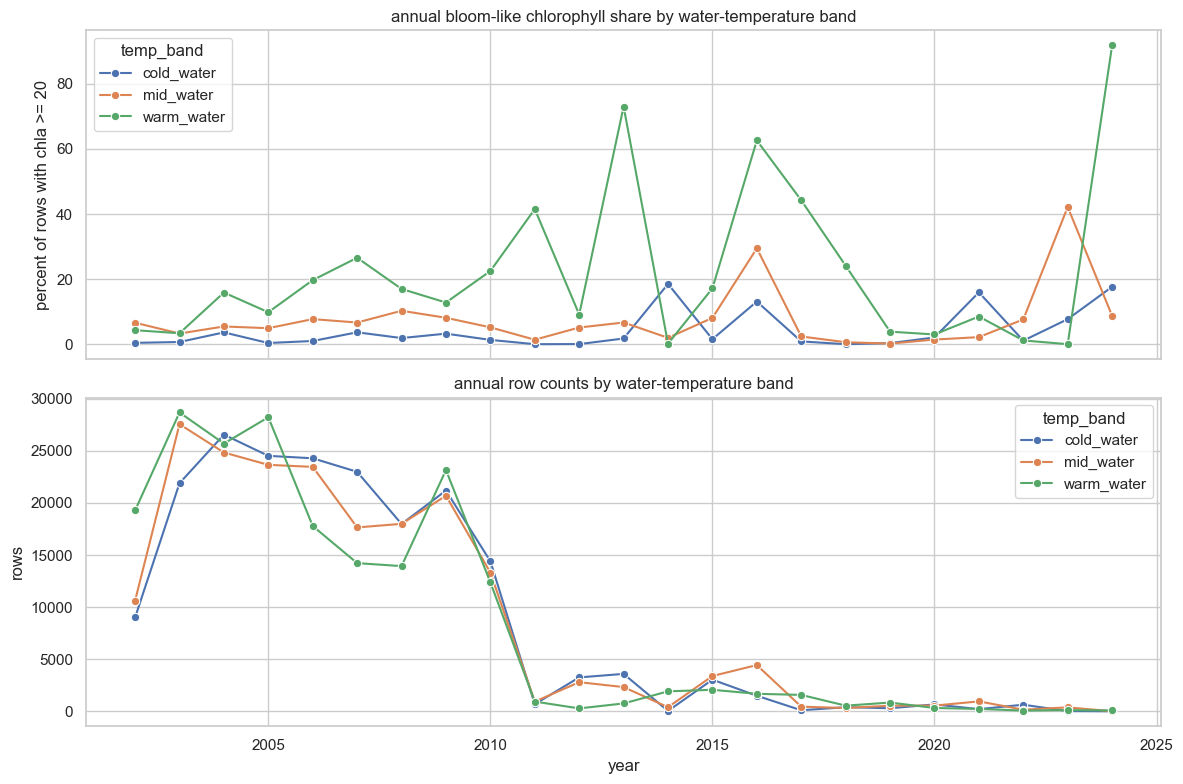

,year,temp_band,bloom_20_plus,n_rows,bloom_20_plus_pct
0,2002,cold_water,0.004103,9017,0.410336
1,2002,mid_water,0.065908,10636,6.590824
2,2002,warm_water,0.042991,19283,4.299124
3,2003,cold_water,0.006713,21897,0.671325
4,2003,mid_water,0.032767,27558,3.276725
5,2003,warm_water,0.033611,28681,3.361110
6,2004,cold_water,0.036225,26556,3.622534
7,2004,mid_water,0.054424,24842,5.442396
8,2004,warm_water,0.158657,25697,15.865665
9,2005,cold_water,0.003630,24521,0.362954


In [ ]:
# show the annual bloom-like share directly and keep row counts nearby for context
annual_bloom_share = annual_temp_state[ [ 'year', 'temp_band', 'bloom_20_plus', 'n_rows' ] ].copy( )
annual_bloom_share[ 'bloom_20_plus_pct' ] = 100 * annual_bloom_share[ 'bloom_20_plus' ]

fig, axes = plt.subplots( 2, 1, figsize = ( 12, 8 ), sharex = True )
sns.lineplot( 
    data = annual_bloom_share,
    x = 'year',
    y = 'bloom_20_plus_pct',
    hue = 'temp_band',
    hue_order = band_order,
    palette = temp_band_palette,
    marker = 'o',
    ax = axes[ 0 ],
)
axes[ 0 ].set_title( 'annual bloom-like chlorophyll share by water-temperature band' )
axes[ 0 ].set_ylabel( 'percent of rows with chla >= 20' )

sns.lineplot( 
    data = annual_bloom_share,
    x = 'year',
    y = 'n_rows',
    hue = 'temp_band',
    hue_order = band_order,
    palette = temp_band_palette,
    marker = 'o',
    ax = axes[ 1 ],
)
axes[ 1 ].set_title( 'annual row counts by water-temperature band' )
axes[ 1 ].set_ylabel( 'rows' )
axes[ 1 ].set_xlabel( 'year' )

plt.tight_layout( )
plt.show( )

annual_bloom_share.head( 12 )


## interpreting the temporal bloom map

These three panels are best read as composition over time within each thermal regime.

A useful pattern to look for is:
- does the `bloom_20_plus` slice grow over time inside warm water?
- does warm water carry a larger bloom share than cold water in most years?
- are changes in bloom share happening together with major changes in the row counts?

That last point matters because a jump in bloom share is more convincing when the corresponding band still has healthy sample counts.
